# Kernel-lifted memory-dominant QRC vs. an edge-of-chaos QRC

**Notebook 5** of this repository.  It builds on `1_QR_Qiskit.ipynb` (recurrent reset-based QRC in Qiskit Aer) and
`4_QR_MixedSYK_Qiskit.ipynb` (mixed SYK2-like/SYK4-like Qiskit gate layer). Neither source notebook is modified, and
Section 22 re-checks their SHA-256 hashes.

The baseline is called the **Kobayashi–Motome-inspired mixed-SYK edge-of-chaos QRC**. It is a Qiskit gate *analogue*
of the mixed SYK2/SYK4 dynamics of K. Kobayashi and Y. Motome, *Edge of Many-Body Quantum Chaos in Quantum Reservoir
Computing*, PRL **136**, 040602 (2026), DOI `10.1103/j2qj-vwcl`. It is **not** the literal fermionic Hamiltonian, and
nothing here claims to reproduce or outperform that paper's implementation.

Code lives in importable, unit-tested modules: `klqrc_quantum.py` (Aer), `klqrc_classical.py` (data, lifts,
statistics) and `klqrc_pipeline.py` (protocol, vault, criteria, audit). This notebook is generated by
`_build_notebook_5_kernel_lifted.py`. Edit the builder, not the notebook.

## 1. Research question and preregistered claims

**Hypothesis.** A causal kernel/Koopman transformation can reorganise a nonlinear forecasting problem into a
representation that needs less nonlinear processing and depends more on temporal memory. When that representation
drives an empirically memory-dominant QRC, the hybrid can outperform a regular QRC operated at the edge of many-body
quantum chaos.

$$\mathbf s^{(d)}_t=[x_t,\dots,x_{t-d+1}]\;\longrightarrow\; z_t=\phi_\theta(\mathbf s^{(d)}_t)\;\longrightarrow\;
r^Q_t\;\longrightarrow\;\hat x_{t+h}\quad(\text{linear ridge readout}).$$

* **H1 – NL-to-memory redistribution.** The lifted representation needs substantially less nonlinear processing than
  the raw one, while accurate prediction still depends on sufficient temporal history.
* **H2 – performance superiority.** `KERNEL_MEMORY_QRC` beats the strongest validation-selected raw/linear-input
  edge-of-chaos QRC (`BEST_EOC_QRC`) on held-out test trajectories.

Forecasting gains alone do not establish H1, and H1 alone does not show that the QRC adds useful computation. Those
are separate claims with separate gates.

### Preregistered success criteria (frozen and hashed in the next cell, before any simulation)

**TRANSFORMATION_PASS** requires all of the following:
1. Volterra: the linear model on the exact lift $\phi^\star$ is within 5 % NRMSE of the raw degree-3 oracle.
2. Volterra: the raw linear model is at least 20 % worse than that oracle.
3. On Mackey–Glass and Lorenz, at every horizon: $G_{\rm NL}^{\rm lift}\le 0.5\,G_{\rm NL}^{\rm raw}$, both at the
   matched history $L=d_{\rm sel}$ and for the median over the memory grid.
4. Adequate history significantly improves the lifted predictor: going from $L=1$ to $L=d_{\rm sel}$ ($q=1$) gives
   at least a 10 % NRMSE reduction, with a paired block-bootstrap 95 % CI that excludes 0.
5. Delay truncation ($d\to\lfloor d/4\rfloor$) and history shuffling each degrade the kernel predictor by at least
   10 %, with a CI that excludes 0.
6. Every criterion also holds separately in each of the ≥ 3 data seeds.
7. Every criterion is evaluated on held-out **test** trajectories.

**BEATS_EOC_PASS** requires all of the following:
1. The EOC κ lies inside the independently diagnosed edge band.
2. The EOC `reps` was selected on validation through a `reps` sweep.
3. For some nontrivial horizon $h\in\{5,10\}$, `KERNEL_MEMORY_QRC` has a lower median test NRMSE than
   `BEST_EOC_QRC` on **both** Mackey–Glass and Lorenz.
4. At that same $h$, $\Delta_{\rm EOC}=(E_{\rm BEST\_EOC}-E_{\rm KERNEL\_MEMORY})/E_{\rm BEST\_EOC}$ is at least 10 %
   on one system and at least 5 % on the other.
5. The paired block-bootstrap 95 % CI of $\Delta_{\rm EOC}$ excludes 0 on both systems.
6. Resources and evaluation samples are matched (audited).
7. `KERNEL_MEMORY_QRC` is no more than 5 % worse than `KERNEL_EOC_QRC` on both systems.

**QRC_VALUE_PASS:** at some $h\in\{5,10\}$ on some system, the hybrid beats kernel-only ridge (ridge on the full
lifted dictionary) by at least 5 %, with a CI that excludes 0.

`FULL_HYPOTHESIS_PASS = TRANSFORMATION_PASS and BEATS_EOC_PASS and QRC_VALUE_PASS`.

**Outcome mapping.** Exactly one outcome is reported, fixed before testing:

| T | B | Q | outcome |
|---|---|---|---|
| ✔ | ✔ | ✔ | 1. Full support |
| ✔ | ✔ | ✘ | 2. Representation-only support |
| ✘ | ✔ | any | 3. Performance-only support |
| ✔ | ✘ | any | 4. EOC not beaten |
| ✘ | ✘ | any | 5. No support under tested conditions |

**Statistics.** NRMSE = RMSE / std(target). Each model's error is the median over (data seed, reservoir seed) units.
CIs come from a paired moving-block bootstrap over test time indices (2000 draws), with the same resampled indices
for both models and every unit of a data seed. The block length is max(40, the largest autocorrelation length of
|test error| over all compared models), rounded up to a multiple of 10.

*Amendment, disclosed:* the original preregistration fixed the block at 40. The first complete execution aborted at
the pitfall audit "block ≥ error autocorrelation length" (measured 62 and 57 samples), before any test metric was
viewed. The block was then made autocorrelation-adaptive, which only makes the CIs more conservative. Nothing else
changed: method, lock record, seeds and thresholds are identical, and the re-run regenerates the same deterministic
test trajectories. The primary run is in scalar mode (one input qubit, the
closest comparison with notebook 4); multichannel mode is secondary and does not enter the certificate.

In [1]:
import json, os, sys
sys.path.insert(0, os.path.abspath('.'))
import klqrc_pipeline as P

CRITERIA_HASH = P.criteria_hash()
print(json.dumps(P.PREREGISTERED, indent=1))
print('\npreregistered-criteria SHA-256:', CRITERIA_HASH)

{
 "transformation": {
  "T1_volterra_lift_within_rel": 0.05,
  "T2_volterra_raw_linear_worse_rel": 0.2,
  "T3_nl_gain_ratio_max": 0.5,
  "T4_memory_min_rel_improvement": 0.1,
  "T5_ablation_min_rel_degradation": 0.1,
  "T6_min_seeds": 3,
  "T7_split": "test"
 },
 "beats_eoc": {
  "B1_eoc_inside_edge_band": true,
  "B2_reps_validation_selected": true,
  "B3_nontrivial_horizons": [
   5,
   10
  ],
  "B4_min_rel_improvement_one_system": 0.1,
  "B4_min_rel_improvement_other_system": 0.05,
  "B5_ci_level": 0.95,
  "B6_resources_matched": true,
  "B7_max_rel_worse_than_kernel_eoc": 0.05
 },
 "qrc_value": {
  "Q1_horizons": [
   5,
   10
  ],
  "Q1_min_rel_improvement_over_kernel_only": 0.05,
  "Q1_ci_excludes_zero": true
 },
 "full_hypothesis": "TRANSFORMATION_PASS and BEATS_EOC_PASS and QRC_VALUE_PASS",
 "memory_qrc_thresholds": {
  "mc_min_frac_of_eoc": 0.9,
  "ipc_nl_max_frac_of_eoc": 0.7
 },
 "statistics": {
  "bootstrap": "paired moving-block over test time indices",
  "block_min": 40

## 2. Environment and reproducibility

`USE_GPU` comes from a *fresh* `AerSimulator().available_devices()` probe (notebook 1's gotcha: a GPU-configured
simulator just echoes 'GPU'), with automatic fallback to CPU. `USE_QPU` is hard-wired to `False`, and nothing in this
notebook can submit an IBM job. Every recurrent QRC runs on `AerSimulator(method="density_matrix")`.

In [2]:
FAST_MODE = True
LONG_RUN = False
USE_QPU = False

import hashlib, platform, subprocess, time, warnings, zlib
from dataclasses import replace
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import qiskit, qiskit_aer, scipy, sklearn
from qiskit_aer import AerSimulator
from IPython.display import Markdown, display
import klqrc_quantum as Q
import klqrc_classical as C


def auto_detect_gpu():
    """True only if a freshly constructed AerSimulator reports a GPU device."""
    return Q.auto_detect_gpu()


USE_GPU = auto_detect_gpu()
DEVICE = 'GPU' if USE_GPU else 'CPU'
assert USE_QPU is False, 'this notebook never submits IBM hardware jobs'
CFG = P.runtime_config(fast_mode=not LONG_RUN, long_run=LONG_RUN)
HZ = tuple(CFG['horizons'])
DATASETS = P.DATASETS
SEEDS, RSEEDS = tuple(CFG['data_seeds']), tuple(CFG['res_seeds'])
RESULTS = os.path.abspath(os.path.join('..', 'results', '5_kernel_lifted'))
FIGS = os.path.join(RESULTS, 'figures')
os.makedirs(FIGS, exist_ok=True)
LEDGER = P.Ledger()
T_START = time.perf_counter()
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 9})


def savefig(name):
    plt.savefig(os.path.join(FIGS, name), dpi=130, bbox_inches='tight')


def med(xs):
    return float(np.median(xs))


ENV = {'python': sys.version.split()[0], 'platform': platform.platform(), 'qiskit': qiskit.__version__,
       'qiskit_aer': qiskit_aer.__version__, 'numpy': np.__version__, 'scipy': scipy.__version__,
       'sklearn': sklearn.__version__, 'aer_devices_fresh_probe': list(AerSimulator().available_devices()),
       'device': DEVICE, 'cpu_count': os.cpu_count(), 'mode': CFG['mode'],
       'disk_feature_cache': os.environ.get('KLQRC_CACHE_DIR')}
for k, v in ENV.items():
    print(f'{k:24s} {v}')
if ENV['disk_feature_cache'] is not None:
    assert os.environ.get('KLQRC_ALLOW_CACHE') == '1', 'final runs must simulate everything fresh (unset KLQRC_CACHE_DIR)'
    print('*** DEVELOPMENT RUN: QRC features may be read from the disk cache ***')
assert P.criteria_hash() == CRITERIA_HASH
print('\nN qubits:', CFG['N'], '| horizons:', HZ, '| data seeds:', SEEDS, '| reservoir seeds:', RSEEDS)
print('usable samples train/val/test:', CFG['n_train'], CFG['n_val'], CFG['n_test'], '| QRC washout:', CFG['washout'])

python                   3.14.4
platform                 Windows-11-10.0.26200-SP0
qiskit                   2.5.2
qiskit_aer               0.17.2
numpy                    2.5.2
scipy                    1.18.1
sklearn                  1.9.0
aer_devices_fresh_probe  ['CPU']
device                   CPU
cpu_count                12
mode                     FAST_MODE
disk_feature_cache       None

N qubits: 6 | horizons: (1, 5, 10) | data seeds: (0, 1, 2) | reservoir seeds: (0, 1, 2)
usable samples train/val/test: 1200 400 400 | QRC washout: 100


## 3. Audit of both source notebooks

Both notebooks were read in full before this one was written. What is reused, and from where:

| component | source | used here as |
|---|---|---|
| `ReservoirConfig` (disorder RNG convention), `chain_edges` | nb1 §0a | `Q.ReservoirConfig` (verbatim); `MultiInputReservoirConfig` draws its Rz disorder through it |
| reset-based recurrent trajectory (only input qubit reset, `Ry(πu)` encoding) | nb1 §0a, nb4 §0c | `Q.run_qrc_jobs` (same convention, generalised to *p* input qubits) |
| `make_simulator` + CPU/GPU safeguard | nb1 §2a | `Q.make_simulator` (verbatim behaviour) |
| exact expectation values | nb1 §0a, nb4 §0c | Re Tr(ρ_mem P) from Aer's per-step reduced density matrix, asserted equal to `save_expectation_value` (§6) |
| `chrono_split`, `select_and_eval_ridge`, `task_narma2`, `random_input` | nb1 §0b | verbatim as `C.nb1_*` for the nb4 regression check; the forecasting pipeline uses *independent trajectories* instead of a chronological split of one series (spec §9) |
| memory capacity | nb1 §0b | generalised: per channel/lag held-out $R^2$ plus Legendre IPC (`C.capacity_profile`) |
| `mixed_layer`, `pauli4_rotation`, `zzzz_rotation`, sparse random 4-body terms, `kappa_to_gJ` | nb4 §0c | verbatim, **single source of truth** for every reservoir |
| `feature_ops_mem_all` (full weight ≤ 3 memory-qubit Pauli readout) | nb4 §0c | verbatim; generalised to several input qubits |
| `level_spacing_ratio`, `sample_reference_r_statistics`, `operator_entanglement`, `otoc_curve`, `scrambling_time` | nb4 §2 | verbatim |
| κ sweep, `reps` sweep, Haar control | nb4 §4, §5, §7 | re-run here on the new forecasting tasks (§12–14) |
| physics/circuit unit tests | nb4 §3 | ported to `tests/test_klqrc.py`, run in §4 |
| memoryless QELM | nb1 §2c | **labelled control only** (§17), never a substitute for the recurrent QRC |

Notebook 4's headline (κ ≈ 0.443, `reps` = 4, NARMA2 NRMSE ≈ 0.27) is used **only** as a regression sanity check
(§4). The edge is re-identified below from physics diagnostics and validation data.

In [3]:
SOURCE_NOTEBOOKS = ('1_QR_Qiskit.ipynb', '4_QR_MixedSYK_Qiskit.ipynb')


def sha256(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()


SOURCE_HASHES = {p: sha256(p) for p in SOURCE_NOTEBOOKS}
SRC = {p: '\n'.join(''.join(c['source']) for c in json.load(open(p, encoding='utf-8'))['cells']
                    if c['cell_type'] == 'code') for p in SOURCE_NOTEBOOKS}
REUSED = {'1_QR_Qiskit.ipynb': ['class ReservoirConfig', 'def make_simulator', 'def chrono_split',
                                'def select_and_eval_ridge', 'def memory_capacity', 'def feature_ops_all',
                                'save_expectation_value', "method='density_matrix'", 'def build_qelm_circuit'],
          '4_QR_MixedSYK_Qiskit.ipynb': ['def mixed_layer', 'def kappa_to_gJ', 'def sample_syk4_terms',
                                         'def pauli4_rotation', 'def feature_ops_mem_all',
                                         'def level_spacing_ratio', 'def operator_entanglement',
                                         'def scrambling_time', 'def build_trajectory_circuit_haar',
                                         'REPS_GRID = np.array([1, 2, 3, 4, 6, 8, 12, 16])',
                                         'def _run_mixed_unit_tests']}
for p, items in REUSED.items():
    print(p, SOURCE_HASHES[p][:16])
    for it in items:
        LEDGER.check(f'source audit: {p} defines `{it}`', it in SRC[p])
nb4 = json.load(open(SOURCE_NOTEBOOKS[1], encoding='utf-8'))
recorded = [''.join(o.get('text', '')) for c in nb4['cells'] if c['cell_type'] == 'code' for o in c.get('outputs', [])]
for line in '\n'.join(recorded).splitlines():
    if line.startswith(('Temporal edge, RECURRENT', 'Performance, RECURRENT', 'NARMA2 best-in-scan')):
        print('nb4 recorded >', line[:200])

1_QR_Qiskit.ipynb a285bbe1c88d632e
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `class ReservoirConfig`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `def make_simulator`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `def chrono_split`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `def select_and_eval_ridge`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `def memory_capacity`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `def feature_ops_all`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `save_expectation_value`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `method='density_matrix'`
  [PASS] source audit: 1_QR_Qiskit.ipynb defines `def build_qelm_circuit`
4_QR_MixedSYK_Qiskit.ipynb 13b24adebe90d3b6
  [PASS] source audit: 4_QR_MixedSYK_Qiskit.ipynb defines `def mixed_layer`
  [PASS] source audit: 4_QR_MixedSYK_Qiskit.ipynb defines `def kappa_to_gJ`
  [PASS] source audit: 4_QR_MixedSYK_Qiskit.ipynb defines `def sample_syk4_terms`
  [PASS] source audit: 4_QR_MixedS

## 4. Reused QRC and mixed-SYK components: unit tests and regression check

`tests/test_klqrc.py` contains notebook 4's physics/circuit tests (ported) and the new tests:
- chunk equivalence;
- fused vs gate-level equivalence;
- equivalence with `save_expectation_value`;
- no future leakage;
- train-only lifts;
- the exact Volterra lift;
- capacity and bootstrap sanity checks.

The regression check below re-runs notebook 4's §7 protocol unchanged (κ = 0.4427, `reps` = 4, seeds 0–2, T = 300,
nb1's split and ridge). It uses this notebook's chunked density-matrix runner, and nb4's recorded NARMA2 is
**0.2706**.

In [4]:
with LEDGER.time('unit_tests'):
    r = subprocess.run([sys.executable, '-m', 'pytest', os.path.join('..', 'tests', 'test_klqrc.py'), '-q',
                        '-p', 'no:cacheprovider'], capture_output=True, text=True)
print(r.stdout[-2500:])
LEDGER.check('all unit tests pass (pytest tests/test_klqrc.py)', r.returncode == 0, r.stdout.strip().splitlines()[-1])
UNIT_TEST_SUMMARY = r.stdout.strip().splitlines()[-1]

KAPPA_NB4 = float(np.geomspace(0.02, 100, 12)[4])
jobs = [Q.QRCJob(Q.mixed_config(6, 1, KAPPA_NB4, 4, s), C.nb1_random_input(300, s)[:, None]) for s in range(3)]
nb4_vals = []
for s, X in enumerate(Q.run_qrc_jobs(jobs, chunk=128, use_memo=False)):
    u = C.nb1_random_input(300, s)
    tr, va, te = C.nb1_chrono_split(300, 20, 70, 130, 6)
    nb4_vals.append(C.nb1_select_and_eval_ridge(X, C.nb1_task_narma2(u), tr, va, te)[0])
NB4_REGRESSION = float(np.mean(nb4_vals))
print(f'kappa={KAPPA_NB4:.4f}, reps=4: NARMA2 NRMSE per seed {np.round(nb4_vals, 4)} -> mean {NB4_REGRESSION:.4f} '
      f'(nb4 recorded 0.2706)')
LEDGER.check('regression: nb4 temporal-edge NARMA2 (0.2706) reproduced', abs(NB4_REGRESSION - 0.2706) < 5e-5,
             f'{NB4_REGRESSION:.5f}')

...........................                                              [100%]
27 passed in 31.06s

  [PASS] all unit tests pass (pytest tests/test_klqrc.py)  (27 passed in 31.06s)


kappa=0.4427, reps=4: NARMA2 NRMSE per seed [0.283  0.2759 0.2529] -> mean 0.2706 (nb4 recorded 0.2706)
  [PASS] regression: nb4 temporal-edge NARMA2 (0.2706) reproduced  (0.27060)


True

## 5. Scalar and multichannel recurrent QRC

`MultiInputReservoirConfig(N, n_input, g, J, reps, seed)` defines the reservoir:
- qubits `0..n_input-1` are reset and re-encoded with $R_y(\pi z_{t,j})$ at every step;
- the remaining memory qubits are **never** reset during a trajectory;
- each step applies `reps` copies of notebook 4's `mixed_layer`;
- only the persistent memory qubits are read out, using the full weight ≤ 3 adjacent Pauli basis.

`n_input = 1` is exactly notebook 4's recurrent reservoir. The tests check this against nb4's own
`build_trajectory_circuit_mixed`.

*Simulation strategy (exact, not an approximation).* Each step's mixed block is appended as one `UnitaryGate`
equal to `Operator(mixed_layer circuit)**reps`. Instead of 132 `save_expectation_value` calls per step, Aer saves the
memory register's reduced density matrix, and each feature is $\mathrm{Re\,Tr}(\rho_{\rm mem}P_k)$. §6 asserts that
both choices reproduce the gate-level, `save_expectation_value` circuit to < 1e-9. Together they make simulation ~40×
faster.

In [5]:
SCALAR_DEMO = Q.mixed_config(CFG['N'], 1, 1.0, CFG['reps_ref'], 0)
MULTI_DEMO = Q.mixed_config(CFG['N'], CFG['multichannel_p'], 1.0, CFG['reps_ref'], 0)
RESOURCES = {}
for name, rc in (('scalar', SCALAR_DEMO), ('multichannel', MULTI_DEMO)):
    res = Q.gate_level_step_resources(rc)
    RESOURCES[name] = dict(N=rc.N, n_input=rc.n_input, memory_qubits=len(rc.memory_qubits),
                           n_features=len(Q.readout_labels(rc)), **res)
    print(f'{name:12s}', RESOURCES[name])
print('QELM control: readout on all qubits ->', len(Q.readout_labels(SCALAR_DEMO, qelm=True)), 'features')

# reset audit on the circuits the runner actually builds
from qiskit.circuit.library import UnitaryGate
zdemo = np.random.default_rng(0).random((25, 2))
for rc, qelm in ((SCALAR_DEMO, False), (MULTI_DEMO, False), (SCALAR_DEMO, True)):
    job = Q.QRCJob(rc, zdemo[:, :rc.n_input], qelm=qelm)
    qa = Q._qelm_angles(job.z, rc.N) if qelm else None
    qc = Q._build_chunk(job, 0, 25, None, UnitaryGate(Q.step_unitary(rc)), qa)
    resets = Q.count_resets_per_qubit(qc)
    expected = {q: 25 for q in (range(rc.N) if qelm else rc.input_qubits)}
    LEDGER.check(f"{'QELM' if qelm else 'recurrent'} n_input={rc.n_input}: resets only on "
                 f"{'all' if qelm else 'input'} qubits, once per step", resets == expected, resets)

scalar       {'N': 6, 'n_input': 1, 'memory_qubits': 5, 'n_features': 132, 'depth_per_step': 594, 'size_per_step': 923, 'cx_per_step': 328}
multichannel {'N': 6, 'n_input': 2, 'memory_qubits': 4, 'n_features': 93, 'depth_per_step': 594, 'size_per_step': 924, 'cx_per_step': 328}
QELM control: readout on all qubits -> 171 features
  [PASS] recurrent n_input=1: resets only on input qubits, once per step  ({0: 25})
  [PASS] recurrent n_input=2: resets only on input qubits, once per step  ({0: 25, 1: 25})
  [PASS] QELM n_input=1: resets only on all qubits, once per step  ({0: 25, 1: 25, 2: 25, 3: 25, 4: 25, 5: 25})


## 6. Chunked-simulation equivalence

Long trajectories are split into chunks of `CFG['chunk']` steps.
- At the end of each chunk, Aer saves the **full** density matrix.
- The next chunk's circuit starts with `set_density_matrix(ρ)`, without resetting any memory qubit.
- Features are concatenated in chronological order.

This is an exact execution strategy, not periodic re-initialisation. The last check shows that a fresh start
*would* differ.

In [6]:
def max_dev(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))


rng = np.random.default_rng(123)
z1, z2 = rng.random((600, 1)), rng.random((300, 2))
rc1, rc2 = Q.mixed_config(CFG['N'], 1, 3.0, 4, 1), Q.mixed_config(CFG['N'], 2, 3.0, 4, 1)
mono1 = Q.run_qrc_jobs([Q.QRCJob(rc1, z1)], chunk=600, use_memo=False)[0]
mono2 = Q.run_qrc_jobs([Q.QRCJob(rc2, z2)], chunk=300, use_memo=False)[0]
EQUIV = {f'scalar T=600, chunk={c}': max_dev(mono1, Q.run_qrc_jobs([Q.QRCJob(rc1, z1)], chunk=c, use_memo=False)[0])
         for c in (37, 128, 256)}
EQUIV['multichannel T=300, chunk=64'] = max_dev(mono2, Q.run_qrc_jobs([Q.QRCJob(rc2, z2)], chunk=64, use_memo=False)[0])
zt = z1[:60, 0]
EQUIV['fused unitary vs gate-level mixed_layer'] = max_dev(
    mono1[:60], Q.run_qrc_jobs([Q.QRCJob(rc1, z1[:60], fuse=False)], chunk=17, use_memo=False)[0])
from qiskit import transpile
qc, labels, *_ = Q.build_trajectory_circuit_mixed(Q.ReservoirConfig(N=CFG['N'], seed=1), zt, rc1.g, rc1.J, rc1.reps,
                                                  term_seed=1)
sim = AerSimulator(method='density_matrix')
d = sim.run(transpile(qc, sim, optimization_level=1), shots=1).result().data(0)
X_nb4 = np.array([[np.real(d[f'{l}__t{t}']) for l in labels] for t in range(len(zt))])
EQUIV['nb4 save_expectation_value circuit vs runner'] = max_dev(X_nb4, mono1[:60])
for k, v in EQUIV.items():
    LEDGER.check(f'exact equivalence: {k} < 1e-9', v < 1e-9, f'max|dX| = {v:.2e}')
fresh = Q.run_qrc_jobs([Q.QRCJob(rc1, z1[256:])], chunk=256, use_memo=False)[0]
print(f'contrast: restarting from |0..0> at t=256 changes features by up to {max_dev(fresh[:5], mono1[256:261]):.3f} '
      '(so chunk continuation is carrying the real state)')

  [PASS] exact equivalence: scalar T=600, chunk=37 < 1e-9  (max|dX| = 0.00e+00)
  [PASS] exact equivalence: scalar T=600, chunk=128 < 1e-9  (max|dX| = 0.00e+00)
  [PASS] exact equivalence: scalar T=600, chunk=256 < 1e-9  (max|dX| = 0.00e+00)
  [PASS] exact equivalence: multichannel T=300, chunk=64 < 1e-9  (max|dX| = 0.00e+00)
  [PASS] exact equivalence: fused unitary vs gate-level mixed_layer < 1e-9  (max|dX| = 3.63e-13)
  [PASS] exact equivalence: nb4 save_expectation_value circuit vs runner < 1e-9  (max|dX| = 2.53e-13)


contrast: restarting from |0..0> at t=256 changes features by up to 0.324 (so chunk continuation is carrying the real state)


## 7. Dataset generation

All series come from separate generator calls with independent initial conditions, one per
(dataset, data seed, split), via `SeedSequence([7919, dataset, seed, split])`.

* **Controlled Volterra.**
  - Input $u_t\sim U(-1,1)$ i.i.d.
  - Target $y_t=0.30u_{t-12}+0.25u_{t-4}u_{t-9}+0.20u_{t-2}u_{t-7}u_{t-11}+0.10y_{t-1}$.
  - Measurement noise is 5 % of the theoretical std(y), so "within 5 %" comparisons sit on a common noise floor.
  - The first 300 samples are discarded.
  - Splits: 4000 / 1000 / 1000 samples.
* **Mackey–Glass.**
  - Parameters β = 0.2, γ = 0.1, n = 10, τ = 17.
  - RK4 with Δt = 0.1, so the history buffer is τ/Δt = 170 points; the delayed value at the half-step is the mean of
    its neighbours.
  - Initial history: a constant $x_0\sim U(0.5,1.3)$ plus ±0.05 noise.
  - 3000 time units of transient are discarded, then the series is sampled every Δ = 3 time units.
* **Lorenz-63.**
  - Parameters σ = 10, ρ = 28, β = 8/3.
  - RK4 with Δt = 0.01, initial condition $(0,0,25)+\mathcal N(0,8^2I)$, 60 time units of transient discarded.
  - Only $x$ is observed, every Δ = 0.1, so the task is partially observed and needs temporal context.

Each forecasting trajectory has $d_{\max}-1+W+n+h_{\max}$ samples, so every model is scored on identical indices.

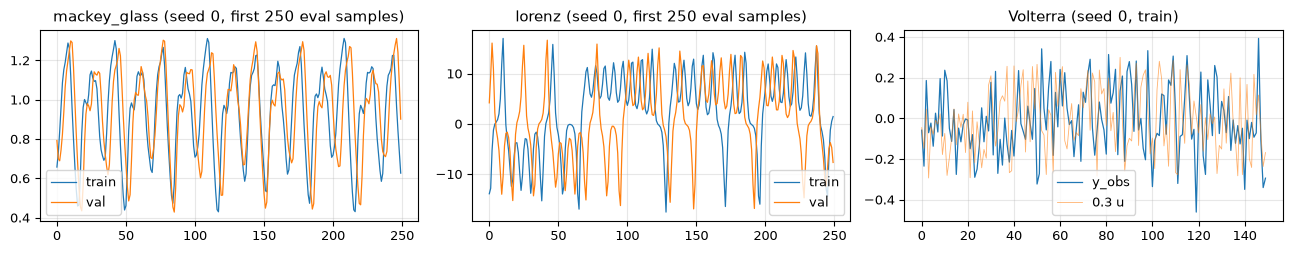

In [7]:
with LEDGER.time('data_dev'):
    DEV = P.build_dev_data(CFG)
    VOLT = {s: {sp: P.volterra_split(CFG, s, sp) for sp in ('train', 'val')} for s in SEEDS}
fig, ax = plt.subplots(1, 3, figsize=(13, 2.6))
for a, ds in zip(ax[:2], DATASETS):
    for sp, c in (('train', 'C0'), ('val', 'C1')):
        t = DEV[ds][0][sp]
        a.plot(t.x[t.eval_idx][:250], c, lw=0.9, label=sp)
    a.set_title(f'{ds} (seed 0, first 250 eval samples)'); a.legend()
u, yc, yo = VOLT[0]['train']
ax[2].plot(yo[:150], lw=0.9, label='y_obs'); ax[2].plot(u[:150] * 0.3, lw=0.6, alpha=0.6, label='0.3 u')
ax[2].set_title('Volterra (seed 0, train)'); ax[2].legend()
plt.tight_layout(); savefig('fig00_datasets.png'); plt.show()

## 8. Causal splitting and normalisation

Split structure:
- train, validation and test are **separate trajectories**, never overlapping windows of one series;
- every split is driven from its own washout;
- every model is scored on the same `eval_idx`, which follows the QRC washout;
- targets are $x_{t+h}$ with $h\ge1$, and windows end at $x_t$.

Every scaler, lift, PCA/SVD and projection is fitted on the training trajectory of the same data seed. Validation and
test inputs are clipped to the training range, and the fraction clipped is reported.

In [8]:
for ds in DATASETS:
    for s, tr in DEV[ds].items():
        for sp, t in tr.items():
            ev = t.eval_idx
            ok = (len(ev) == CFG[f'n_{sp}'] and ev.min() - (CFG['d_max'] - 1) >= 0
                  and ev.max() + max(HZ) < len(t.x) and np.all(ev[:, None] - np.arange(CFG['d_max'])[None] < ev[:, None] + min(HZ)))
            if not ok:
                LEDGER.check(f'{ds} seed {s} {sp}: causal windows / targets', False)
        dmin = P.min_segment_distance(tr['train'].x, tr['val'].x, CFG['d_max'])
        LEDGER.check(f'{ds} seed {s}: train/val are separate trajectories (no shared {CFG["d_max"]}-sample segment; '
                     f'min L_inf segment distance {dmin:.3g})', dmin > 1e-6 and tr['train'].x[0] != tr['val'].x[0])
LEDGER.check('identical evaluation length for every split/seed/dataset',
             len({(sp, len(t.eval_idx)) for ds in DATASETS for tr in DEV[ds].values() for sp, t in tr.items()}) == 2)
CLIP_RAW = {ds: med([P.fit_inputs(C.LiftSpec('raw', 1), DEV[ds][s], CFG)[2]['val'] for s in SEEDS]) for ds in DATASETS}
print('fraction of validation raw inputs clipped by the train-derived [0,1] scaling:', CLIP_RAW)

  [PASS] mackey_glass seed 0: train/val are separate trajectories (no shared 32-sample segment; min L_inf segment distance 0.00889)
  [PASS] mackey_glass seed 1: train/val are separate trajectories (no shared 32-sample segment; min L_inf segment distance 0.00471)


  [PASS] mackey_glass seed 2: train/val are separate trajectories (no shared 32-sample segment; min L_inf segment distance 0.0128)
  [PASS] lorenz seed 0: train/val are separate trajectories (no shared 32-sample segment; min L_inf segment distance 0.915)


  [PASS] lorenz seed 1: train/val are separate trajectories (no shared 32-sample segment; min L_inf segment distance 0.263)
  [PASS] lorenz seed 2: train/val are separate trajectories (no shared 32-sample segment; min L_inf segment distance 0.392)
  [PASS] identical evaluation length for every split/seed/dataset
fraction of validation raw inputs clipped by the train-derived [0,1] scaling: {'mackey_glass': 0.0, 'lorenz': 0.0}


## 9. Kernel / Koopman lifting and Stage-1 screening (validation only)

Candidate representations, all fitted on the training trajectory only:

* **raw/current input** $z_t=x_t$ (or $[x_t,x_{t-1}]$ in multichannel mode);
* **dimension-matched linear delay embedding** $z_t=P\mathbf s^{(d)}_t$, with $P$ either train-PCA or the linear
  reduced-rank forecast projection (`pred`, below);
* **nonlinear lifts** of the standardised window:
  - an RBF dictionary $\psi_j=\exp(-\gamma\lVert\mathbf s-c_j\rVert^2)$ with $m\in\{8,16,32\}$ centres
    Nyström-sampled from distinct training windows, and $\gamma=b/(2\,\mathrm{median}^2)$ for
    $b\in\{0.5,1,2\}\times$ the training median-distance scale;
  - degree-2 and degree-3 polynomial dictionaries, capped at 600 features.

The dictionary is reduced to the QRC input dimension *p* by one of three train-fitted projections:
- train-PCA;
- **`pred`**: a reduced-rank EDMD/Koopman forecast projection, i.e. the top-*p* singular directions of the train
  ridge map $\psi_t\mapsto[x_{t+1},\dots,x_{t+10}]$;
- **`pred1`**: the minimal-horizon version, $\psi_t\mapsto[x_{t+1},\dots,x_{t+p}]$. For $p=1$ this is the kernel
  one-step Koopman forecast coordinate.
Coordinates are MinMax-scaled to [0,1] with training statistics.

**Stage 1 (inexpensive).** For every candidate:
- validation EDMD closure, 10-step rollout, reconstruction $R^2$ of $x_t$ and $C A^h\psi$ forecast errors;
- a *memory proxy*: linear ridge on the last 8 values of $z$, which mimics a linear fading-memory reservoir.

Candidates with reconstruction $R^2<0.95$, which have low transition error only because they discard the signal, are
rejected, as are pathological Gram matrices. The top `shortlist_kernel` nonlinear candidates (by median-over-seeds
mean-over-horizons proxy NRMSE) go to QRC validation, each with its matched linear counterpart (same *d*, projection
and *p*).

In [9]:
SCREEN_ROWS, SCREENED = {ds: [] for ds in DATASETS}, set()
with LEDGER.time('screening_round1'):
    specs = P.candidate_specs(CFG)
    for ds in DATASETS:
        SCREEN_ROWS[ds] += P.screen(DEV, ds, CFG, specs)
    SCREENED |= set(specs)
SHORT = {ds: P.shortlist(SCREEN_ROWS[ds], CFG['shortlist_kernel']) for ds in DATASETS}
RAW_PROXY = {ds: {h: med([P.proxy_val(P.fit_inputs(C.LiftSpec('raw', 1), DEV[ds][s], CFG)[1], DEV[ds][s], CFG)[h]
                          for s in SEEDS]) for h in HZ} for ds in DATASETS}
for ds in DATASETS:
    rows = sorted(SCREEN_ROWS[ds], key=lambda r: r['proxy_J_val'])
    print(f'\n=== {ds}: {len(rows)} candidates, {sum(r["rejected"] for r in rows)} rejected ===')
    print(f"{'candidate':38s} {'J_val':>6s} " + ' '.join(f'h={h:<4d}' for h in HZ) + '  recon  closure EDMD(h5)')
    for r in [r for r in rows if r['spec'].nonlinear][:8] + [r for r in rows if r['family'] == 'linear'][:3]:
        print(f"{r['name']:38s} {r['proxy_J_val']:6.3f} " + ' '.join(f"{r[f'proxy_val_h{h}']:.3f} " for h in HZ)
              + f" {r['recon_r2']:.4f} {r['closure_rel_err']:.1e} {r['edmd_nrmse_h5']:.3f}"
              + ('  REJECTED' if r['rejected'] else ''))
    print('raw x_t proxy:', {h: round(v, 3) for h, v in RAW_PROXY[ds].items()})
    print('SHORTLIST:', [s.name for s in SHORT[ds]])


=== mackey_glass: 243 candidates, 12 rejected ===
candidate                               J_val h=1    h=5    h=10    recon  closure EDMD(h5)
poly2|d=32|pred|p=1                     0.207 0.207  0.199  0.216  1.0000 9.9e-07 0.007
poly2|d=24|pred|p=1                     0.212 0.209  0.202  0.222  1.0000 2.6e-06 0.010
poly3|d=8|pred|p=1                      0.226 0.212  0.219  0.246  1.0000 5.5e-05 0.045
poly2|d=16|pred|p=1                     0.244 0.218  0.245  0.269  1.0000 1.9e-05 0.028
rbf[m=32,bw=2]|d=8|pred|p=1             0.257 0.224  0.248  0.303  0.9997 2.6e-04 0.041
rbf[m=32,bw=1]|d=8|pred|p=1             0.275 0.190  0.254  0.374  0.9998 3.5e-04 0.050
rbf[m=16,bw=2]|d=8|pred|p=1             0.281 0.221  0.297  0.326  0.9985 1.8e-03 0.088
rbf[m=32,bw=2]|d=16|pred|p=1            0.288 0.219  0.275  0.375  0.9996 1.8e-04 0.064
linear|d=32|pred1|p=1                   0.423 0.094  0.546  0.629  1.0000 2.4e-04 0.340
linear|d=1|pred|p=1                     0.424 0.111  0.520  0.641

## 10. Controlled Volterra witness (validation view)

Because the delays and nonlinear orders are known, this task gives an *algebraic* demonstration. Every model is
fitted on train (α on val) and scored on common indices $t\ge24$. The models are:
1. raw linear on 25 taps;
2. the raw **degree-3 oracle** on 15 taps (815 monomials);
3. **linear** on the exact lift $\phi^\star_t=[u_{t-12},\,u_{t-4}u_{t-9},\,u_{t-2}u_{t-7}u_{t-11}]$ and its two
   previous values, which covers the $0.1\,y_{t-1}$ recursion; this is a linear-memory model on the lifted
   coordinates;
4. the exact lift with one monomial removed, compared with the analytic residual
   $\sqrt{(c_k^2\,3^{-|k|}/(1-0.1^2)+\sigma^2)/\mathrm{Var}(y)}$;
5. a degree-3 model on a delay truncated to 8 taps;
6. history-shuffled windows (current $u_t$ kept, past taps from a random other time).

The hand-typed lift is also checked against the generic implementation. The **test** version, which feeds the
certificate, runs in §18 after the lock.

In [10]:
with LEDGER.time('volterra_val'):
    VW_VAL = {s: C.volterra_witness(VOLT[s], 'val', shuffle_seed=s) for s in SEEDS}
print(f"{'model':26s}" + ''.join(f'  seed{s}' for s in SEEDS) + '   expected')
for m in C.VOLTERRA_MODELS:
    exp = VW_VAL[SEEDS[0]][m].get('expected_nrmse')
    print(f'{m:26s}' + ''.join(f'  {VW_VAL[s][m]["nrmse"]:.3f}' for s in SEEDS) + (f'   {exp:.3f}' if exp else ''))
print('noise floor', round(VW_VAL[SEEDS[0]]['noise_floor_nrmse'], 4), '| exact-lift |generic-manual| max:',
      max(VW_VAL[s]['exact_lift_max_abs_diff'] for s in SEEDS))

model                       seed0  seed1  seed2   expected
raw_linear                  0.478  0.457  0.478
raw_deg3_oracle             0.059  0.059  0.058
lift_linear                 0.051  0.052  0.052
lift_drop_0                 0.887  0.878  0.895   0.897
lift_drop_1                 0.430  0.420  0.437   0.434
lift_drop_2                 0.205  0.190  0.210   0.205
delay_truncated_deg3        1.010  1.015  0.998
lift_history_shuffled       1.000  1.001  1.001
oracle_history_shuffled     1.047  1.062  1.051
noise floor 0.0507 | exact-lift |generic-manual| max: 0.0


## 11. Memory–nonlinearity response surfaces (validation view)

$E_R(L,q)$ is the validation NRMSE of a causal predictor:
- representation $R$, built from the last $L$ samples;
- polynomial/Volterra degree $q$: all base features, plus every degree-2..q monomial of the top-10 train-PCA
  coordinates of the base, so the models are nested in $q$;
- $q=1$ is a strictly linear memory model.

Representations: raw taps; a train-PCA linear embedding; the lift applied to $L$-windows (refitted per $L$).
History is matched by construction ($L$ samples for every $R$).

$$G^R_{\rm NL}(L)=\frac{E_R(L,1)-\min_{q>1}E_R(L,q)}{E_R(L,1)+\epsilon},\qquad
G^R_{\rm M}(q)=\frac{E_R(L_{\min},q)-E_R(L_{\max},q)}{E_R(L_{\min},q)+\epsilon}.$$

Here the lift is the current top-ranked screened kernel. The locked kernel's **test** surfaces (figures 1–4) are in
§18.

In [11]:
TOP1 = {ds: SHORT[ds][0] for ds in DATASETS}
with LEDGER.time('surfaces_val'):
    SURF_VAL = {ds: {s: C.response_surface(DEV[ds][s]['train'], DEV[ds][s]['val'], DEV[ds][s]['val'], TOP1[ds],
                                            CFG['memory_grid'], CFG['degree_grid'], HZ) for s in SEEDS}
                for ds in DATASETS}
for ds in DATASETS:
    print(f'\n{ds}: lift = {TOP1[ds].name}   (median over seeds; validation)')
    for h in HZ:
        Ls = [L for L in CFG['memory_grid'] if all((L, 1, h) in SURF_VAL[ds][s]['lift'] for s in SEEDS)]
        g_raw = [med([C.nl_gain(SURF_VAL[ds][s]['raw'], L, CFG['degree_grid'], h) for s in SEEDS]) for L in Ls]
        g_lift = [med([C.nl_gain(SURF_VAL[ds][s]['lift'], L, CFG['degree_grid'], h) for s in SEEDS]) for L in Ls]
        print(f'  h={h:2d}  L={Ls}\n        G_NL raw ={np.round(g_raw, 3)}\n        G_NL lift={np.round(g_lift, 3)}')


mackey_glass: lift = poly2|d=32|pred|p=1   (median over seeds; validation)
  h= 1  L=[1, 2, 4, 8, 16, 24, 32]
        G_NL raw =[0.003 0.196 0.736 0.975 0.913 0.839 0.769]
        G_NL lift=[ 3.000e-03  1.460e-01  7.590e-01  8.380e-01 -1.490e-01 -9.525e+00
 -1.987e+01]
  h= 5  L=[1, 2, 4, 8, 16, 24, 32]
        G_NL raw =[0.027 0.497 0.837 0.956 0.957 0.94  0.907]
        G_NL lift=[ 0.017  0.188  0.933  0.934  0.1   -2.759 -5.697]
  h=10  L=[1, 2, 4, 8, 16, 24, 32]
        G_NL raw =[0.025 0.218 0.752 0.913 0.932 0.928 0.882]
        G_NL lift=[ 0.033  0.221  0.899  0.907  0.473 -1.097 -3.708]

lorenz: lift = poly3|d=8|pred|p=1   (median over seeds; validation)
  h= 1  L=[1, 2, 4, 8]
        G_NL raw =[0.105 0.737 0.909 0.751]
        G_NL lift=[ 0.007  0.313 -0.098 -1.522]
  h= 5  L=[1, 2, 4, 8]
        G_NL raw =[0.076 0.2   0.4   0.424]
        G_NL lift=[ 0.02   0.211  0.024 -0.131]
  h=10  L=[1, 2, 4, 8]
        G_NL raw =[0.028 0.064 0.241 0.266]
        G_NL lift=[ 0.002  0.09

## 12. Independent QRC capacity characterisation

The capacity runs use **i.i.d.** $u_t\sim U(0,1)$, never forecasting data, so a reservoir's measured memory and
nonlinearity cannot be tuned on the task.

Each (κ, `reps`, reservoir seed) gets one trajectory. The chronological train/val/test readout blocks are separated
by guard gaps longer than the longest lag. Because the input sequence depends only on the reservoir seed, κ and
`reps` are compared under common random numbers.

* $MC_{j,k}$ is the held-out $R^2$ of a linear readout of $u_{j,t-k}$, for $k=0..20$; $MC_{\rm total}=\sum
  \mathrm{clip}(MC_{j,k},0,1)$. The unclipped sum is reported diagnostically.
* $IPC_2$, $IPC_3$ sum the clipped held-out $R^2$ of every orthonormal Legendre product of total degree 2 (lags ≤ 10,
  66 targets) or 3 (lags ≤ 6, 84 targets). This covers same-channel, cross-channel (multichannel mode) and
  mixed-delay products of $v=2u-1$.
  - Capacities below a **null threshold** are set to zero. The threshold is the 99th percentile of the capacities of
    matching Legendre targets built from an independent sequence that never entered the reservoir.
  - Unthresholded sums are also reported.
  - Ridge α is chosen on the validation block.

In [12]:
CAP_CONFIGS = [Q.mixed_config(CFG['N'], 1, k, r, rs) for k in CFG['kappa_grid'] for r in CFG['reps_grid']
               for rs in RSEEDS]
with LEDGER.time('capacity_scan_grid'):
    CAP_ROWS = P.capacity_scan(CAP_CONFIGS, CFG, use_gpu=USE_GPU)
CAP = P.capacity_medians(CAP_ROWS, P.ckey)
print(f'{len(CAP_CONFIGS)} capacity trajectories; Aer steps {LEDGER.timings["capacity_scan_grid"]["aer_steps"]:,}')
print(f"\nreps={CFG['reps_ref']}:  kappa |  MC_total  IPC2   IPC3   IPC_NL | null thr")
thr = {P.ckey(r['cfg']): r['ipc_null_threshold'] for r in CAP_ROWS}
for k in CFG['kappa_grid']:
    key = (round(k, 6), CFG['reps_ref'])
    c = CAP[key]
    print(f"            {k:8.3f} | {c['mc_total']:7.3f} {c['ipc2']:6.3f} {c['ipc3']:6.3f} {c['ipc_nl']:6.3f} | {thr[key]:.3f}")

288 capacity trajectories; Aer steps 761,184

reps=4:  kappa |  MC_total  IPC2   IPC3   IPC_NL | null thr
               0.020 |   6.863 21.231 28.601 49.832 | 0.011
               0.043 |   6.920 21.710 29.224 50.933 | 0.011
               0.094 |   6.885 20.924 28.575 49.499 | 0.012
               0.204 |   6.597 20.134 28.947 49.080 | 0.012
               0.443 |   6.522 20.146 29.079 49.225 | 0.010
               0.960 |   6.531 20.336 28.564 48.901 | 0.014
               2.083 |   6.695 20.366 28.432 48.798 | 0.010
               4.518 |   7.396 22.534 29.746 52.280 | 0.008
               9.799 |  12.607 29.329 24.113 53.441 | 0.009
              21.255 |  15.890 16.826  4.908 21.733 | 0.017
              46.103 |   6.438  2.166  0.046  2.212 | 0.005
             100.000 |   0.513  0.105  0.003  0.108 | 0.012


## 13. Parametric edge diagnostics

The diagnostics follow notebook 4's methodology, now on a dense 40-point κ grid with 15 disorder seeds:
- ⟨r⟩ and the OTOC scrambling time $t^\ast$ (first layer where $2(1-\mathrm{Re}F)\ge0.5$) use the single layer;
- $S_{\rm op}$ uses the `reps`-fold step operator;
- Poisson/COE/CUE ⟨r⟩ references are calibrated numerically at $d=2^N$. The mixed layer has no anti-unitary
  symmetry, so the chaotic reference is CUE.

**Preregistered edge band** (the analogue of Kobayashi–Motome Fig. 4's dashed lines). Let
$\eta(\kappa)=(\langle r\rangle-r_P)/(r_{\rm CUE}-r_P)$, using the median over seeds.
- $\kappa_{\rm lo}$ is the largest κ that is still fully chaotic ($\eta\ge0.9$).
- $\kappa_{\rm hi}$ is the first larger κ that has reached Poisson ($\eta\le0.1$).

The band is fixed from physics alone. Its forecasting candidates are 4 log-spaced κ values in
$[\kappa_{\rm lo},\kappa_{\rm hi}]$, plus any grid κ inside it. The EOC κ is the best of these on validation.
Validation error over the whole grid is shown for context only.

In [13]:
with LEDGER.time('edge_physics'):
    PHYS = P.edge_physics(CFG)
K_LO, K_HI = PHYS['kappa_lo'], PHYS['kappa_hi']
REFS = PHYS['refs']
print('reference <r> at d=2^N:', {k: f'{v[0]:.4f}+/-{v[1]:.4f}' for k, v in REFS.items()})
print(f'EDGE BAND (physics only): kappa in [{K_LO:.3f}, {K_HI:.3f}]; band points {np.round(PHYS["band_points"], 3)}')
band_cfgs = [Q.mixed_config(CFG['N'], 1, k, r, rs) for k in PHYS['band_points'] for r in CFG['reps_grid'] for rs in RSEEDS]
with LEDGER.time('capacity_scan_band'):
    CAP_ROWS += P.capacity_scan(band_cfgs, CFG, use_gpu=USE_GPU)
CAP = P.capacity_medians(CAP_ROWS, P.ckey)
KAPPA_SCAN = sorted({round(k, 6) for k in CFG['kappa_grid']} | {round(k, 6) for k in PHYS['band_points']})
IN_BAND = lambda k: K_LO * (1 - 1e-9) <= k <= K_HI * (1 + 1e-9)

reference <r> at d=2^N: {'poisson': '0.3858+/-0.0410', 'cue': '0.5996+/-0.0371', 'coe': '0.5276+/-0.0417'}
EDGE BAND (physics only): kappa in [3.778, 21.681]; band points [ 3.778  6.765 12.11  21.681]


In [14]:
EOC_INPUTS = {}
for ds in DATASETS:
    seen, lst = set(), [C.LiftSpec('raw', 1)]
    for s in SHORT[ds]:
        lc = s.linear_counterpart()
        if lc.name not in seen:
            seen.add(lc.name); lst.append(lc)
    EOC_INPUTS[ds] = lst
groups = {(ds, k, inp.name): P.paired_entries(DEV, ds, inp, P.kappa_rc(CFG, k, CFG['reps_ref']), CFG, 'kscan')
          for ds in DATASETS for k in KAPPA_SCAN for inp in EOC_INPUTS[ds]}
with LEDGER.time('kappa_scan_val'):
    KSCAN = P.run_groups(groups, CFG, use_gpu=USE_GPU)
LEDGER.budget['eoc_side_val_evals'] += len(groups)
KJ = {key: P.score_J(v, HZ) for key, v in KSCAN.items()}
for ds in DATASETS:
    print(f'\n{ds}: validation J (reps={CFG["reps_ref"]}); * = inside edge band')
    print(f"{'kappa':>9s} " + ' '.join(f'{inp.name[:22]:>23s}' for inp in EOC_INPUTS[ds]))
    for k in KAPPA_SCAN:
        print(f"{k:9.3f}{'*' if IN_BAND(k) else ' '}" + ' '.join(f'{KJ[(ds, k, inp.name)]:23.4f}' for inp in EOC_INPUTS[ds]))


mackey_glass: validation J (reps=4); * = inside edge band
    kappa                raw(p=1)    linear|d=32|pred|p=1    linear|d=24|pred|p=1     linear|d=8|pred|p=1
    0.020                  0.0061                  0.0610                  0.0432                  0.0149
    0.043                  0.0069                  0.0556                  0.0411                  0.0172
    0.094                  0.0065                  0.0672                  0.0432                  0.0158
    0.204                  0.0066                  0.0654                  0.0431                  0.0183
    0.443                  0.0067                  0.0651                  0.0448                  0.0184
    0.960                  0.0064                  0.0651                  0.0447                  0.0179
    2.083                  0.0065                  0.0710                  0.0481                  0.0165
    3.778*                 0.0068                  0.0681                  0.0401            

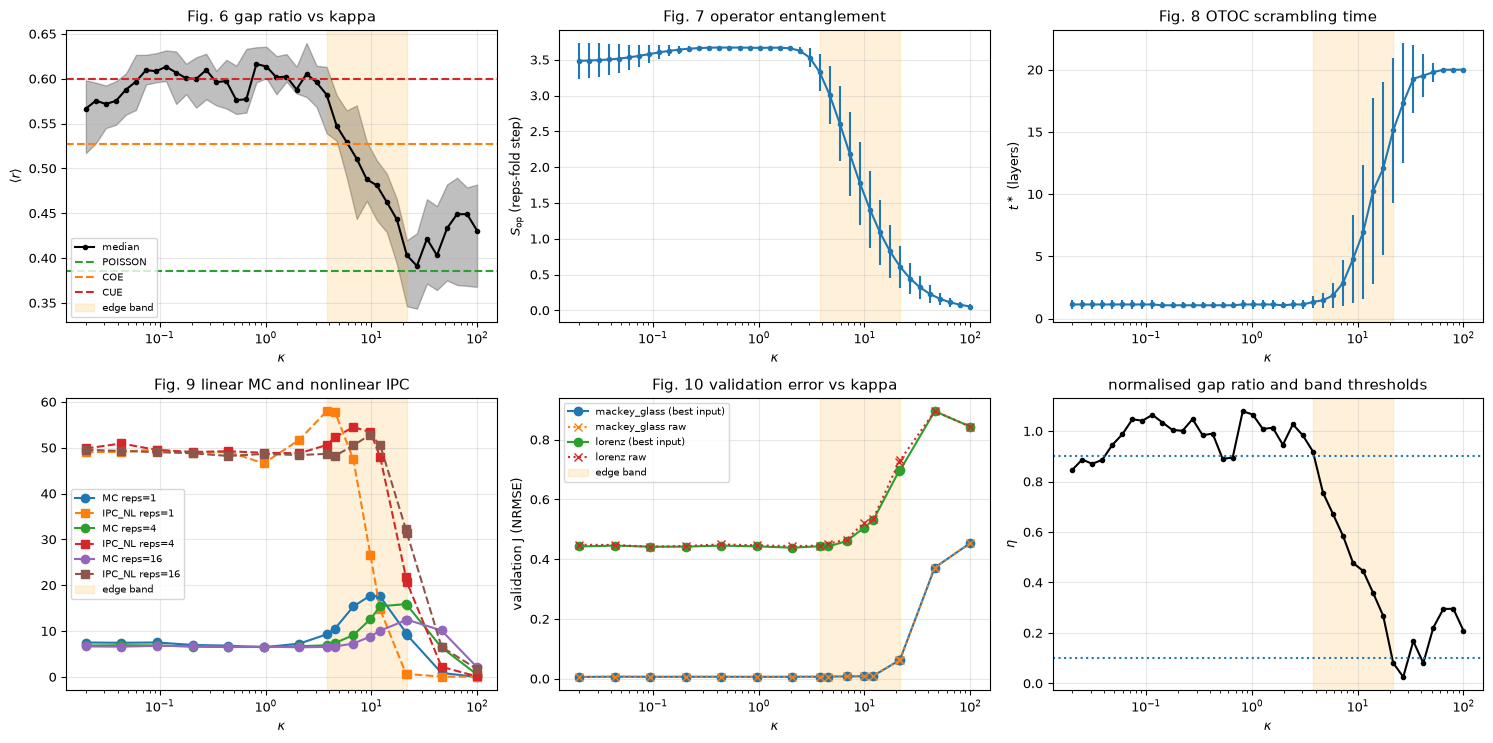

In [15]:
kd, kg = np.array(CFG['kappa_dense']), np.array(CFG['kappa_grid'])
fig, ax = plt.subplots(2, 3, figsize=(15, 7.5))
def shade(a):
    a.axvspan(K_LO, K_HI, color='orange', alpha=0.15, label='edge band'); a.set_xscale('log'); a.set_xlabel(r'$\kappa$')
a = ax[0, 0]
q = np.percentile(PHYS['dense']['r'], [25, 50, 75], axis=1)
a.plot(kd, q[1], 'k.-', label='median'); a.fill_between(kd, q[0], q[2], alpha=0.25, color='k')
for nm, c in (('poisson', 'C2'), ('coe', 'C1'), ('cue', 'C3')):
    a.axhline(REFS[nm][0], color=c, ls='--', label=nm.upper())
shade(a); a.set_ylabel(r'$\langle r\rangle$'); a.set_title('Fig. 6 gap ratio vs kappa'); a.legend(fontsize=7)
a = ax[0, 1]
a.errorbar(kd, PHYS['dense']['S_op'].mean(1), PHYS['dense']['S_op'].std(1), fmt='o-', ms=3)
shade(a); a.set_ylabel(r'$S_{\rm op}$ (reps-fold step)'); a.set_title('Fig. 7 operator entanglement')
a = ax[0, 2]
a.errorbar(kd, PHYS['dense']['t_star'].mean(1), PHYS['dense']['t_star'].std(1), fmt='o-', ms=3)
shade(a); a.set_ylabel(r'$t^\ast$ (layers)'); a.set_title('Fig. 8 OTOC scrambling time')
a = ax[1, 0]
for r_ in (1, CFG['reps_ref'], 16):
    ks = sorted({k for (k, rr) in CAP if rr == r_})
    a.plot(ks, [CAP[(k, r_)]['mc_total'] for k in ks], 'o-', label=f'MC reps={r_}')
    a.plot(ks, [CAP[(k, r_)]['ipc_nl'] for k in ks], 's--', label=f'IPC_NL reps={r_}')
shade(a); a.set_title('Fig. 9 linear MC and nonlinear IPC'); a.legend(fontsize=7)
a = ax[1, 1]
for ds in DATASETS:
    a.plot(KAPPA_SCAN, [min(KJ[(ds, k, i.name)] for i in EOC_INPUTS[ds]) for k in KAPPA_SCAN], 'o-', label=f'{ds} (best input)')
    a.plot(KAPPA_SCAN, [KJ[(ds, k, 'raw(p=1)')] for k in KAPPA_SCAN], 'x:', label=f'{ds} raw')
shade(a); a.set_ylabel('validation J (NRMSE)'); a.set_title('Fig. 10 validation error vs kappa'); a.legend(fontsize=7)
a = ax[1, 2]
a.plot(kd, PHYS['eta_dense'], 'k.-'); a.axhline(0.9, ls=':'); a.axhline(0.1, ls=':'); shade(a)
a.set_ylabel(r'$\eta$'); a.set_title('normalised gap ratio and band thresholds')
plt.tight_layout(); savefig('fig06_10_parametric_edge.png'); plt.show()

## 14. Temporal edge diagnostics

For each dataset, the two best in-band κ values (validation, each with its best input) are swept over
`reps` ∈ {1,2,3,4,6,8,12,16}, the discrete analogue of the input interval $\Delta t_{\rm in}$. The comparisons are:
- short evolution (`reps` = 1);
- long, strongly scrambled evolution (`reps` = 16);
- notebook 4's Haar control, where one fixed Haar-random 6-qubit unitary per step replaces the mixed block.

The locked EOC model, **`RAW_EOC_QRC` / `BEST_EOC_QRC` reservoir**, is (κ, `reps`) = argmin of validation J. The
step operator's scrambling is reported against `reps`.

mackey_glass: EOC locked at kappa=3.7785 (in band: True), reps=2, input=raw(p=1), val J=0.0060 | reps=1: 0.0074  reps=16: 0.0062  Haar: 0.0066
     EOC capacities: MC=7.550 IPC2=23.305 IPC3=29.265
lorenz: EOC locked at kappa=4.5177 (in band: True), reps=16, input=linear|d=8|pred1|p=1, val J=0.4401 | reps=1: 0.4864  reps=16: 0.4401  Haar: 0.4444
     EOC capacities: MC=6.635 IPC2=20.551 IPC3=27.642


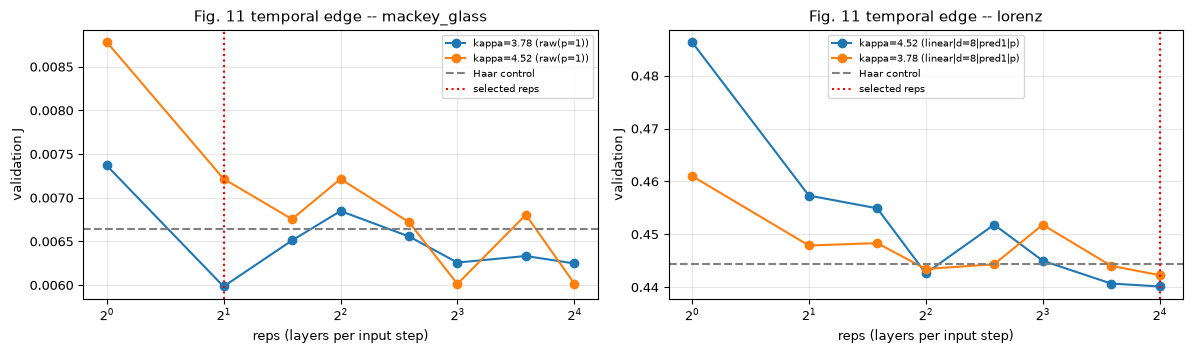

mackey_glass step-operator diagnostics at EOC kappa: [(1, 1.896, 1.0), (2, 2.878, 0.5), (3, 3.244, 0.3333333333333333), (4, 3.35, 0.25), (6, 3.506, 0.16666666666666666), (8, 3.588, 0.125), (12, 3.599, 0.08333333333333333), (16, 3.612, 0.0625)]
lorenz step-operator diagnostics at EOC kappa: [(1, 1.626, 1.0), (2, 2.511, 0.5), (3, 2.948, 0.3333333333333333), (4, 3.125, 0.25), (6, 3.36, 0.16666666666666666), (8, 3.438, 0.125), (12, 3.535, 0.08333333333333333), (16, 3.547, 0.0625)]


In [16]:
EOC, TEMPORAL = {}, {}
groups = {}
for ds in DATASETS:
    best_by_k = {k: min(EOC_INPUTS[ds], key=lambda i: KJ[(ds, k, i.name)]) for k in KAPPA_SCAN if IN_BAND(k)}
    ranked = sorted(best_by_k, key=lambda k: KJ[(ds, k, best_by_k[k].name)])
    TEMPORAL[ds] = {'kappas': ranked[:2], 'inputs': {k: best_by_k[k] for k in ranked[:2]}}
    for k in ranked[:2]:
        for r_ in CFG['reps_grid']:
            if r_ != CFG['reps_ref']:
                groups[(ds, k, r_)] = P.paired_entries(DEV, ds, best_by_k[k], P.kappa_rc(CFG, k, r_), CFG, 'temporal')
    groups[(ds, 'haar')] = P.paired_entries(DEV, ds, best_by_k[ranked[0]], P.haar_rc(CFG), CFG, 'haar')
with LEDGER.time('temporal_scan_val'):
    TSCAN = P.run_groups(groups, CFG, use_gpu=USE_GPU)
LEDGER.budget['eoc_side_val_evals'] += len(groups)
for ds in DATASETS:
    T_ = TEMPORAL[ds]
    T_['J'] = {}
    for k in T_['kappas']:
        for r_ in CFG['reps_grid']:
            T_['J'][(k, r_)] = KJ[(ds, k, T_['inputs'][k].name)] if r_ == CFG['reps_ref'] else P.score_J(TSCAN[(ds, k, r_)], HZ)
    T_['J_haar'] = P.score_J(TSCAN[(ds, 'haar')], HZ)
    (kE, rE) = min(T_['J'], key=T_['J'].get)
    EOC[ds] = {'kappa': kE, 'reps': rE, 'input': T_['inputs'][kE], 'J_val': T_['J'][(kE, rE)],
               'key': (round(kE, 6), rE), 'inside_band': IN_BAND(kE), 'reps_validation_selected': True}
    print(f"{ds}: EOC locked at kappa={kE:.4f} (in band: {IN_BAND(kE)}), reps={rE}, input={EOC[ds]['input'].name}, "
          f"val J={EOC[ds]['J_val']:.4f} | reps=1: {T_['J'][(kE, 1)]:.4f}  reps=16: {T_['J'][(kE, 16)]:.4f}  Haar: {T_['J_haar']:.4f}")
    c = CAP[EOC[ds]['key']]
    print(f"     EOC capacities: MC={c['mc_total']:.3f} IPC2={c['ipc2']:.3f} IPC3={c['ipc3']:.3f}")

TEMPORAL_DIAG = {}
for ds in DATASETS:
    kE = EOC[ds]['kappa']
    rows = []
    for r_ in CFG['reps_grid']:
        sops, ts = [], []
        for seed in range(CFG['n_diag_seeds']):
            U1 = Q.layer_unitary(Q.mixed_config(CFG['N'], 1, kE, 1, seed))
            sops.append(Q.operator_entanglement(np.linalg.matrix_power(U1, r_), CFG['N']))
            ts.append(Q.scrambling_time(U1, CFG['N'], 0, CFG['N'] - 1)[0])
        rows.append({'reps': r_, 'S_op': med(sops), 't_star_layers': med(ts), 't_star_in_steps': med(ts) / r_})
    TEMPORAL_DIAG[ds] = rows
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, ds in zip(ax, DATASETS):
    T_ = TEMPORAL[ds]
    for k in T_['kappas']:
        a.plot(CFG['reps_grid'], [T_['J'][(k, r_)] for r_ in CFG['reps_grid']], 'o-', label=f'kappa={k:.2f} ({T_["inputs"][k].name[:18]})')
    a.axhline(T_['J_haar'], color='gray', ls='--', label='Haar control')
    a.axvline(EOC[ds]['reps'], color='r', ls=':', label='selected reps')
    a.set_xscale('log', base=2); a.set_xlabel('reps (layers per input step)'); a.set_ylabel('validation J')
    a.set_title(f'Fig. 11 temporal edge -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); savefig('fig11_temporal_edge.png'); plt.show()
for ds in DATASETS:
    print(ds, 'step-operator diagnostics at EOC kappa:', [(r['reps'], round(r['S_op'], 3), r['t_star_in_steps']) for r in TEMPORAL_DIAG[ds]])

## 15. Validation-only kernel/delay search and memory-dominant QRC selection

**Memory-dominant candidates** come from *measured* capacities, not assumed from κ or `reps`. A candidate is feasible
when
$MC\ge0.9\,MC_{\rm EOC}$ and $IPC_{\rm NL}\le0.7\,IPC_{\rm NL,EOC}$.
- Feasible configurations are ranked along their Pareto front (max MC, min IPC_NL), and the top
  `max_mem_candidates` are kept.
- If nothing is feasible, that failure is reported and the closest Pareto point is used. The thresholds are never
  relaxed.

**Stage 2.** Every shortlisted kernel × memory candidate is evaluated on validation, and the best becomes
`KERNEL_MEMORY_QRC`.
- The procedure has up to `MAX_VALIDATION_ROUNDS` = 3 rounds. If the hybrid does not beat `BEST_EOC_QRC` on
  validation, the predetermined expansions apply: round 2 adds larger dictionaries and bandwidths; round 3 widens the
  shortlist and the memory candidates.
- **`BEST_EOC_QRC`** uses the locked EOC (κ, `reps`) with the best validation input among the raw input and the
  linear counterparts of every shortlisted kernel.
- Budgets are counted. The memory/hybrid side is never given more validation evaluations than the EOC side.

In [17]:
TH = P.PREREGISTERED['memory_qrc_thresholds']
MEMC, MEM_INFO = {}, {}
for ds in DATASETS:
    keys, feasible, info = P.memory_candidates(CAP, EOC[ds]['key'], TH, CFG['max_mem_candidates'])
    MEMC[ds], MEM_INFO[ds] = keys, dict(info, thresholds_met=feasible)
    print(f"{ds}: memory thresholds MC>={info['mc_min']:.3f}, IPC_NL<={info['ipc_nl_max']:.3f}; feasible configs: "
          f"{info['n_feasible']}; candidates (kappa, reps): {keys}" + ('' if feasible else '  ** THRESHOLDS NOT MET **'))
    for k in keys:
        print(f"      {k}: MC={CAP[k]['mc_total']:.3f} IPC2={CAP[k]['ipc2']:.3f} IPC3={CAP[k]['ipc3']:.3f}")

def eval_best_eoc(ds, inputs):
    g = {i.name: P.paired_entries(DEV, ds, i, P.kappa_rc(CFG, EOC[ds]['kappa'], EOC[ds]['reps']), CFG, 'best_eoc')
         for i in inputs}
    res = P.run_groups(g, CFG, use_gpu=USE_GPU)
    LEDGER.budget['eoc_side_val_evals'] += len(g)
    return {i.name: (i, P.score_J(res[i.name], HZ)) for i in inputs}

BEST_EOC_CANDS = {ds: eval_best_eoc(ds, EOC_INPUTS[ds]) for ds in DATASETS}
KM_J, ROUND_LOG = {ds: {} for ds in DATASETS}, []
cfg_r = dict(CFG)
todo_ds = list(DATASETS)          # datasets whose hybrid does not yet beat BEST_EOC on validation
for rnd in range(1, CFG['max_validation_rounds'] + 1):
    if rnd > 1:                   # predetermined expansion, applied only to datasets still pending
        for key, val in P.ROUND_EXPANSIONS[rnd - 1].items():
            cfg_r[key] = tuple(sorted(set(cfg_r[key]) | set(val))) if isinstance(val, tuple) else val
        new_specs = [s for s in P.candidate_specs(cfg_r) if s not in SCREENED]
        with LEDGER.time(f'screening_round{rnd}'):
            for ds in todo_ds:
                SCREEN_ROWS[ds] += P.screen(DEV, ds, CFG, new_specs)
        SCREENED |= set(new_specs)
        for ds in todo_ds:
            SHORT[ds] = P.shortlist(SCREEN_ROWS[ds], cfg_r['shortlist_kernel'])
            MEMC[ds] = P.memory_candidates(CAP, EOC[ds]['key'], TH, cfg_r['max_mem_candidates'])[0]
            new_lin = [s.linear_counterpart() for s in SHORT[ds] if s.linear_counterpart().name not in BEST_EOC_CANDS[ds]]
            if new_lin:
                BEST_EOC_CANDS[ds].update(eval_best_eoc(ds, new_lin))
    groups = {(ds, ks.name, mk): (ks, P.paired_entries(DEV, ds, ks, P.kappa_rc(CFG, *mk), CFG, 'km'))
              for ds in todo_ds for ks in SHORT[ds] for mk in MEMC[ds] if (ks.name, mk) not in KM_J[ds]}
    with LEDGER.time(f'kernel_memory_val_round{rnd}'):
        res = P.run_groups({k: v[1] for k, v in groups.items()}, CFG, use_gpu=USE_GPU)
    LEDGER.budget['memory_side_val_evals'] += len(groups)
    for (ds, nm, mk), (ks, _) in groups.items():
        KM_J[ds][(nm, mk)] = (ks, P.score_J(res[(ds, nm, mk)], HZ))
    still = []
    for ds in todo_ds:
        (nm, mk), (ks, j) = min(KM_J[ds].items(), key=lambda kv: kv[1][1])
        bnm, (bi, bj) = min(BEST_EOC_CANDS[ds].items(), key=lambda kv: kv[1][1])
        ROUND_LOG.append({'round': rnd, 'dataset': ds, 'best_kernel': nm, 'memory_key': mk, 'J_kernel_memory': j,
                          'best_eoc_input': bnm, 'J_best_eoc': bj, 'n_km_evaluated': len(KM_J[ds])})
        print(f'round {rnd} {ds}: KERNEL_MEMORY {nm} @ {mk}: J={j:.4f} | BEST_EOC {bnm}: J={bj:.4f}')
        if j >= bj:
            still.append(ds)
    todo_ds = still
    if not todo_ds:
        break
N_ROUNDS_USED = rnd
LOCKED = {}
for ds in DATASETS:
    (nm, mk), (ks, j) = min(KM_J[ds].items(), key=lambda kv: kv[1][1])
    bnm, (bi, bj) = min(BEST_EOC_CANDS[ds].items(), key=lambda kv: kv[1][1])
    LOCKED[ds] = {'kernel': ks, 'memory_key': mk, 'eoc_key': EOC[ds]['key'], 'best_eoc_input': bi,
                  'J_val_kernel_memory': j, 'J_val_best_eoc': bj}
print('\nrounds used:', N_ROUNDS_USED, '| budgets:', LEDGER.budget)

mackey_glass: memory thresholds MC>=6.795, IPC_NL<=36.800; feasible configs: 21; candidates (kappa, reps): [(9.799186, 1), (12.110478, 1), (21.254946, 2), (21.68115, 2)]
      (9.799186, 1): MC=17.760 IPC2=20.822 IPC3=5.789
      (12.110478, 1): MC=17.548 IPC2=12.105 IPC3=2.611
      (21.254946, 2): MC=14.786 IPC2=9.801 IPC3=1.146
      (21.68115, 2): MC=14.596 IPC2=9.120 IPC3=1.015
lorenz: memory thresholds MC>=5.972, IPC_NL<=33.735; feasible configs: 21; candidates (kappa, reps): [(9.799186, 1), (12.110478, 1), (21.254946, 2), (21.68115, 2)]
      (9.799186, 1): MC=17.760 IPC2=20.822 IPC3=5.789
      (12.110478, 1): MC=17.548 IPC2=12.105 IPC3=2.611
      (21.254946, 2): MC=14.786 IPC2=9.801 IPC3=1.146
      (21.68115, 2): MC=14.596 IPC2=9.120 IPC3=1.015


round 1 mackey_glass: KERNEL_MEMORY poly2|d=32|pred|p=1 @ (9.799186, 1): J=0.0222 | BEST_EOC raw(p=1): J=0.0060
round 1 lorenz: KERNEL_MEMORY poly3|d=8|pred|p=1 @ (9.799186, 1): J=0.5465 | BEST_EOC linear|d=8|pred1|p=1: J=0.4401


round 2 mackey_glass: KERNEL_MEMORY poly2|d=32|pred|p=1 @ (9.799186, 1): J=0.0222 | BEST_EOC raw(p=1): J=0.0060
round 2 lorenz: KERNEL_MEMORY poly3|d=8|pred|p=1 @ (9.799186, 1): J=0.5465 | BEST_EOC linear|d=8|pred1|p=1: J=0.4401


round 3 mackey_glass: KERNEL_MEMORY rbf[m=64,bw=4]|d=8|pred|p=1 @ (9.799186, 1): J=0.0201 | BEST_EOC raw(p=1): J=0.0060
round 3 lorenz: KERNEL_MEMORY poly3|d=8|pred|p=1 @ (9.799186, 1): J=0.5465 | BEST_EOC linear|d=8|pred1|p=1: J=0.4401

rounds used: 3 | budgets: {'eoc_side_val_evals': 166, 'memory_side_val_evals': 80}


## 16. Locked factorial experiment (definition and validation view)

| input representation | memory-dominant QRC | edge-of-chaos QRC |
|---|---|---|
| raw/linear (the `BEST_EOC` input) | `RAW_MEMORY_QRC` | `BEST_EOC_QRC` |
| nonlinear kernel lift | `KERNEL_MEMORY_QRC` | `KERNEL_EOC_QRC` |

The four cells use identical trajectories, total qubits (N = 6), input qubits (1), memory qubits (5), observables
(132), ridge-α grid, seeds, targets and test indices. `RAW_EOC_QRC` and `LINEAR_DELAY_EOC_QRC` (the locked kernel's
linear counterpart) are also reported.

There is one supplementary reference: `UNCONSTRAINED_QRC`, the best validation κ over the *whole* κ grid at
`reps_ref`. It shows whether restricting the baseline to the edge band weakened it, and it plays no role in any
criterion.

**Multichannel (secondary).** The same 2×2 is repeated with p = 2 input qubits (N = 6, 4 memory qubits,
93 observables) for every condition.
- The kernel uses the top-2 `pred` coordinates.
- The raw/linear input is $[x_t,x_{t-1}]$ or the 2-D linear counterpart, chosen on validation.
- The reservoir (κ, `reps`) is inherited from the scalar lock, with no extra tuning for either arm.

In [18]:
groups = {}
UNCON = {}
for ds in DATASETS:
    k_u, i_u = min(((k, i) for k in KAPPA_SCAN for i in EOC_INPUTS[ds]), key=lambda ki: KJ[(ds, ki[0], ki[1].name)])
    UNCON[ds] = {'kappa': k_u, 'reps': CFG['reps_ref'], 'input': i_u, 'J_val': KJ[(ds, k_u, i_u.name)], 'inside_band': IN_BAND(k_u)}
    lk = LOCKED[ds]
    groups[(ds, 'KERNEL_EOC_QRC')] = P.paired_entries(DEV, ds, lk['kernel'], P.kappa_rc(CFG, *lk['eoc_key']), CFG, '')
    groups[(ds, 'RAW_MEMORY_QRC')] = P.paired_entries(DEV, ds, lk['best_eoc_input'], P.kappa_rc(CFG, *lk['memory_key']), CFG, '')
    p = CFG['multichannel_p']
    K2 = replace(lk['kernel'], p=p)
    MC_IN = {'raw': C.LiftSpec('raw', p, p=p), 'linear': K2.linear_counterpart(), 'kernel': K2}
    LOCKED[ds]['multichannel'] = MC_IN
    for nm, sp in MC_IN.items():
        for arm, key in (('EOC', lk['eoc_key']), ('MEM', lk['memory_key'])):
            groups[(ds, f'MC_{nm}_{arm}')] = P.paired_entries(DEV, ds, sp, P.kappa_rc(CFG, *key, n_input=p), CFG, '')
with LEDGER.time('factorial_val'):
    FVAL = P.run_groups(groups, CFG, use_gpu=USE_GPU)
LEDGER.budget['eoc_side_val_evals'] += sum(1 for k in groups if k[1].endswith('EOC') or k[1] == 'KERNEL_EOC_QRC')
LEDGER.budget['memory_side_val_evals'] += sum(1 for k in groups if k[1].endswith('MEM') or k[1] == 'RAW_MEMORY_QRC')
for ds in DATASETS:
    lk = LOCKED[ds]
    lk['J_val_kernel_eoc'] = P.score_J(FVAL[(ds, 'KERNEL_EOC_QRC')], HZ)
    lk['J_val_raw_memory'] = P.score_J(FVAL[(ds, 'RAW_MEMORY_QRC')], HZ)
    mcj = {k[1]: P.score_J(v, HZ) for k, v in FVAL.items() if k[0] == ds and k[1].startswith('MC_')}
    lk['mc_best_eoc_input'] = 'raw' if mcj['MC_raw_EOC'] <= mcj['MC_linear_EOC'] else 'linear'
    lk['mc_val'] = mcj
    print(f"\n{ds}: kernel={lk['kernel'].name} | EOC (kappa,reps)={lk['eoc_key']} | MEMORY={lk['memory_key']} | "
          f"BEST_EOC input={lk['best_eoc_input'].name}")
    print(f"   validation J: BEST_EOC={lk['J_val_best_eoc']:.4f}  RAW_MEMORY={lk['J_val_raw_memory']:.4f}  "
          f"KERNEL_MEMORY={lk['J_val_kernel_memory']:.4f}  KERNEL_EOC={lk['J_val_kernel_eoc']:.4f}  "
          f"(UNCONSTRAINED kappa={UNCON[ds]['kappa']:.3f}: {UNCON[ds]['J_val']:.4f})")
    print('   multichannel validation J:', {k: round(v, 4) for k, v in mcj.items()}, '-> BEST_EOC input:', lk['mc_best_eoc_input'])

MC_CAP_CFGS = [Q.mixed_config(CFG['N'], CFG['multichannel_p'], *LOCKED[ds][key], rs)
               for ds in DATASETS for key in ('eoc_key', 'memory_key') for rs in RSEEDS]
MC_CAP_CFGS = list({c.key(): c for c in MC_CAP_CFGS}.values())
with LEDGER.time('capacity_multichannel'):
    MC_CAP = P.capacity_medians(P.capacity_scan(MC_CAP_CFGS, CFG, n_input=CFG['multichannel_p'], use_gpu=USE_GPU), P.ckey)
for k, v in MC_CAP.items():
    print('multichannel capacity', k, {m: round(x, 3) for m, x in v.items()})


mackey_glass: kernel=rbf[m=64,bw=4]|d=8|pred|p=1 | EOC (kappa,reps)=(3.778498, 2) | MEMORY=(9.799186, 1) | BEST_EOC input=raw(p=1)
   validation J: BEST_EOC=0.0060  RAW_MEMORY=0.0296  KERNEL_MEMORY=0.0201  KERNEL_EOC=0.0091  (UNCONSTRAINED kappa=0.020: 0.0061)
   multichannel validation J: {'MC_raw_EOC': 0.0104, 'MC_raw_MEM': 0.0237, 'MC_linear_EOC': 0.0268, 'MC_linear_MEM': 0.0269, 'MC_kernel_EOC': 0.0168, 'MC_kernel_MEM': 0.0132} -> BEST_EOC input: raw

lorenz: kernel=poly3|d=8|pred|p=1 | EOC (kappa,reps)=(4.517727, 16) | MEMORY=(9.799186, 1) | BEST_EOC input=linear|d=8|pred1|p=1
   validation J: BEST_EOC=0.4401  RAW_MEMORY=0.6776  KERNEL_MEMORY=0.5465  KERNEL_EOC=0.3877  (UNCONSTRAINED kappa=2.083: 0.4385)
   multichannel validation J: {'MC_raw_EOC': 0.438, 'MC_raw_MEM': 0.6004, 'MC_linear_EOC': 0.4909, 'MC_linear_MEM': 0.675, 'MC_kernel_EOC': 0.3375, 'MC_kernel_MEM': 0.4164} -> BEST_EOC input: raw


multichannel capacity (3.778498, 2) {'mc_total': 7.165, 'mc_total_unclipped': 6.978, 'ipc2': 19.298, 'ipc3': 20.959, 'ipc2_unthresholded': 19.379, 'ipc3_unthresholded': 21.271, 'ipc_nl': 40.257, 'n_seeds': 3}
multichannel capacity (9.799186, 1) {'mc_total': 16.455, 'mc_total_unclipped': 16.455, 'ipc2': 17.334, 'ipc3': 4.716, 'ipc2_unthresholded': 17.432, 'ipc3_unthresholded': 4.785, 'ipc_nl': 22.05, 'n_seeds': 3}
multichannel capacity (4.517727, 16) {'mc_total': 6.023, 'mc_total_unclipped': 5.784, 'ipc2': 16.938, 'ipc3': 20.944, 'ipc2_unthresholded': 16.998, 'ipc3_unthresholded': 21.111, 'ipc_nl': 37.883, 'n_seeds': 3}


## 17. Classical and QELM controls (validation selection), then the lock

Controls, with every hyperparameter chosen on validation:
1. persistence;
2. linear AR on raw taps ($d$ from the delay grid);
3. degree-2/3 polynomial AR (feature count ≤ 600);
4. **kernel-only ridge**: ridge on the full lifted dictionary of the locked kernel, with no QRC;
5. kernel-scalar ridge on $z_t$ alone and on its last 8 values;
6. the EDMD/Koopman linear predictor $\hat x_{t+h}=CA^h\psi_t$;
7. **kernel-lifted memoryless QELM**, a *labelled control*:
   - every qubit is reset each step, and the last 6 values of $z$ are encoded on 6 qubits;
   - the locked EOC mixed block follows, with the full weight ≤ 3 readout on all qubits;
   - it runs on the density-matrix simulator, because of the repository's known statevector-reset defect;
   - it is a memoryless quantum feature map with classical delay encoding, **not** recurrent quantum memory;
8. a state-dimension-matched (132-unit) classical ESN on the kernel input and on the raw input, with spectral radius
   and input scale chosen on validation.

After this cell the method is **locked**. The lock record is hashed, and the vault refuses to release test data
otherwise, or more than once.

In [19]:
def readout_split(feats, trajs, splits_out=('val',)):
    preds, alpha = P.readout(feats, trajs, HZ, splits_out)
    return preds


def classical_feats(kind, ds, s, trajs, param=None):
    """Eval-row feature matrices for a classical control, fitted on train."""
    W = CFG['washout']
    if kind == 'ar':
        return {sp: C.windows(t.x, param, t.eval_idx) for sp, t in trajs.items()}
    if kind == 'polyar':
        deg, d = param
        S = {sp: C.windows(t.x, d, t.eval_idx) for sp, t in trajs.items()}
        mu, sd = S['train'].mean(0), S['train'].std(0)
        pf = C.PolynomialFeatures(deg, include_bias=False).fit((S['train'] - mu) / sd)
        return {sp: pf.transform((v - mu) / sd) for sp, v in S.items()}
    if kind in ('kernel_only', 'kernel_scalar1', 'kernel_scalar8', 'esn_kernel', 'esn_raw'):
        spec = LOCKED[ds]['kernel'] if kind != 'esn_raw' else C.LiftSpec('raw', 1)
        lf, z, _ = P.fit_inputs(spec, trajs, CFG)
        if kind == 'kernel_only':
            return {sp: lf.psi(t.x, t.eval_idx) for sp, t in trajs.items()}
        if kind.startswith('kernel_scalar'):
            n = int(kind[-1])
            return {sp: C.lag_stack(z[sp], n)[W:] for sp in trajs}
        rho, scale, rs = param
        return {sp: C.esn_features(z[sp], 132, rho, scale, seed=rs)[W:] for sp in trajs}
    raise KeyError(kind)


AR_GRID = list(CFG['delay_grid'])
POLY_GRID = [(deg, d) for deg in (2, 3) for d in CFG['delay_grid'] if C.poly_feature_count(d, deg) <= C.MAX_POLY_FEATURES]
CTRL_SEL, CTRL_VAL = {}, {}
with LEDGER.time('controls_val'):
    for ds in DATASETS:
        sel = {}
        def J_of(kind, param, seeds_units):
            out = []
            for s, rs in seeds_units:
                tr = DEV[ds][s]
                pr = readout_split(classical_feats(kind, ds, s, tr, param if rs is None else (*param, rs)), tr)
                out.append(np.mean(list(P.unit_nrmse(pr, tr, HZ, 'val').values())))
            return med(out)
        units0 = [(s, None) for s in SEEDS]
        sel['ar'] = min(AR_GRID, key=lambda d: J_of('ar', d, units0))
        sel['polyar'] = min(POLY_GRID, key=lambda p: J_of('polyar', p, units0))
        unitsR = [(s, s) for s in SEEDS]
        sel['esn_kernel'] = min(CFG['esn_grid'], key=lambda p: J_of('esn_kernel', p, unitsR))
        sel['esn_raw'] = min(CFG['esn_grid'], key=lambda p: J_of('esn_raw', p, unitsR))
        CTRL_SEL[ds] = sel
        CTRL_VAL[ds] = {'persistence': med([np.mean([C.nrmse(DEV[ds][s]['val'].x[DEV[ds][s]['val'].eval_idx],
                                                               DEV[ds][s]['val'].target(h)) for h in HZ]) for s in SEEDS]),
                        'linear_AR': J_of('ar', sel['ar'], units0), 'poly_AR': J_of('polyar', sel['polyar'], units0),
                        'kernel_only_ridge': J_of('kernel_only', None, units0),
                        'kernel_scalar_ridge(z_t)': J_of('kernel_scalar1', None, units0),
                        'kernel_scalar_ridge(8 lags)': J_of('kernel_scalar8', None, units0),
                        'ESN_kernel': J_of('esn_kernel', sel['esn_kernel'], unitsR),
                        'ESN_raw': J_of('esn_raw', sel['esn_raw'], unitsR)}
        print(f'{ds}: selected', sel)
        print('   validation J:', {k: round(v, 4) for k, v in CTRL_VAL[ds].items()})
qelm_groups = {ds: P.paired_entries(DEV, ds, LOCKED[ds]['kernel'], P.kappa_rc(CFG, *LOCKED[ds]['eoc_key']), CFG,
                                    'qelm', qelm=True) for ds in DATASETS}
QELM_VAL = P.run_groups(qelm_groups, CFG, use_gpu=USE_GPU)
for ds in DATASETS:
    CTRL_VAL[ds]['QELM_kernel (memoryless control)'] = P.score_J(QELM_VAL[ds], HZ)
    print(ds, 'QELM control validation J:', round(CTRL_VAL[ds]['QELM_kernel (memoryless control)'], 4))

LOCK_RECORD = {'criteria_hash': CRITERIA_HASH, 'mode': CFG['mode'], 'data_seeds': SEEDS, 'res_seeds': RSEEDS,
               'edge_band': [K_LO, K_HI], 'rounds_used': N_ROUNDS_USED, 'budget': LEDGER.budget,
               'locked': {ds: {'kernel': LOCKED[ds]['kernel'].name, 'eoc_key': LOCKED[ds]['eoc_key'],
                               'memory_key': LOCKED[ds]['memory_key'],
                               'best_eoc_input': LOCKED[ds]['best_eoc_input'].name,
                               'mc_best_eoc_input': LOCKED[ds]['mc_best_eoc_input'], 'controls': CTRL_SEL[ds],
                               'unconstrained': (UNCON[ds]['kappa'], UNCON[ds]['input'].name)} for ds in DATASETS}}
VAULT = P.TestVault(P.test_builder(CFG))
LOCK_HASH = VAULT.lock(LOCK_RECORD)
print(json.dumps(VAULT.lock_record, indent=1))
print('\nMETHOD LOCKED. lock hash', LOCK_HASH)

mackey_glass: selected {'ar': 32, 'polyar': (2, 32), 'esn_kernel': (0.95, 0.3), 'esn_raw': (0.8, 1.0)}
   validation J: {'persistence': 1.2797, 'linear_AR': 0.2951, 'poly_AR': 0.0052, 'kernel_only_ridge': 0.0151, 'kernel_scalar_ridge(z_t)': 0.5993, 'kernel_scalar_ridge(8 lags)': 0.2333, 'ESN_kernel': 0.0084, 'ESN_raw': 0.0072}


lorenz: selected {'ar': 16, 'polyar': (3, 8), 'esn_kernel': (0.5, 1.0), 'esn_raw': (0.5, 1.0)}
   validation J: {'persistence': 1.0453, 'linear_AR': 0.761, 'poly_AR': 0.4024, 'kernel_only_ridge': 0.4024, 'kernel_scalar_ridge(z_t)': 0.7816, 'kernel_scalar_ridge(8 lags)': 0.6508, 'ESN_kernel': 0.3978, 'ESN_raw': 0.4268}


mackey_glass QELM control validation J: 0.0143
lorenz QELM control validation J: 0.3718
{
 "criteria_hash": "1eb908125fb33bbae739fa26b530b9f725adc7c2a9bca07b0fbc1b93e5d3625a",
 "mode": "FAST_MODE",
 "data_seeds": [
  0,
  1,
  2
 ],
 "res_seeds": [
  0,
  1,
  2
 ],
 "edge_band": [
  3.778498,
  21.68115
 ],
 "rounds_used": 3,
 "budget": {
  "eoc_side_val_evals": 174,
  "memory_side_val_evals": 88
 },
 "locked": {
  "mackey_glass": {
   "kernel": "rbf[m=64,bw=4]|d=8|pred|p=1",
   "eoc_key": [
    3.778498,
    2
   ],
   "memory_key": [
    9.799186,
    1
   ],
   "best_eoc_input": "raw(p=1)",
   "mc_best_eoc_input": "raw",
   "controls": {
    "ar": 32,
    "polyar": [
     2,
     32
    ],
    "esn_kernel": [
     0.95,
     0.3
    ],
    "esn_raw": [
     0.8,
     1.0
    ]
   },
   "unconstrained": [
    0.02,
    "raw(p=1)"
   ]
  },
  "lorenz": {
   "kernel": "poly3|d=8|pred|p=1",
   "eoc_key": [
    4.517727,
    16
   ],
   "memory_key": [
    9.799186,
    1
   ],
   "best

## 18. Locked test evaluation (single release of the test trajectories)

The criteria were printed in §1 and frozen (hash-checked at the lock and at release). Each dataset's test
trajectories are generated **now**, exactly once. Every Aer run below adds a test split, while train/validation
features are re-simulated or re-used under identical keys. Readout α is still chosen on validation, and the test
split is only scored.

In [20]:
TEST = {ds: VAULT.release(ds) for ds in DATASETS}
TEST_VOLT = VAULT.release('volterra')
FULL = {ds: {s: {'train': DEV[ds][s]['train'], 'val': DEV[ds][s]['val'], 'test': TEST[ds][s]} for s in SEEDS}
        for ds in DATASETS}
UNITS = [(s, rs) for s in SEEDS for rs in RSEEDS]
SPL = ('train', 'val', 'test')
groups = {}
for ds in DATASETS:
    lk = LOCKED[ds]
    eoc, mem = P.kappa_rc(CFG, *lk['eoc_key']), P.kappa_rc(CFG, *lk['memory_key'])
    kern = lk['kernel']
    E = lambda spec, rc, **kw: P.paired_entries(None, ds, spec, rc, CFG, '', seeds_pairs=UNITS, splits=SPL,
                                                trajs_override=FULL[ds], **kw)
    groups[(ds, 'RAW_EOC_QRC')] = E(C.LiftSpec('raw', 1), eoc)
    groups[(ds, 'LINEAR_DELAY_EOC_QRC')] = E(kern.linear_counterpart(), eoc)
    if lk['best_eoc_input'].name not in ('raw(p=1)', kern.linear_counterpart().name):
        groups[(ds, 'BEST_EOC_QRC')] = E(lk['best_eoc_input'], eoc)
    groups[(ds, 'RAW_MEMORY_QRC')] = E(lk['best_eoc_input'], mem)
    groups[(ds, 'KERNEL_MEMORY_QRC')] = E(kern, mem)
    groups[(ds, 'KERNEL_EOC_QRC')] = E(kern, eoc)
    groups[(ds, 'QELM_KERNEL_CONTROL')] = E(kern, eoc, qelm=True)
    groups[(ds, 'UNCONSTRAINED_QRC')] = E(UNCON[ds]['input'], P.kappa_rc(CFG, UNCON[ds]['kappa'], UNCON[ds]['reps']))
    groups[(ds, 'ABLATION_DELAY_TRUNCATED')] = E(replace(kern, d=max(1, kern.d // 4)), mem)
    groups[(ds, 'ABLATION_HISTORY_SHUFFLED')] = E(kern, mem, S_mode='shuffle')
    p = CFG['multichannel_p']
    mcin = lk['multichannel']
    best2 = mcin[lk['mc_best_eoc_input']]
    groups[(ds, 'MC_BEST_EOC_QRC')] = E(best2, P.kappa_rc(CFG, *lk['eoc_key'], n_input=p))
    groups[(ds, 'MC_RAW_MEMORY_QRC')] = E(best2, P.kappa_rc(CFG, *lk['memory_key'], n_input=p))
    groups[(ds, 'MC_KERNEL_MEMORY_QRC')] = E(mcin['kernel'], P.kappa_rc(CFG, *lk['memory_key'], n_input=p))
    groups[(ds, 'MC_KERNEL_EOC_QRC')] = E(mcin['kernel'], P.kappa_rc(CFG, *lk['eoc_key'], n_input=p))
with LEDGER.time('test_qrc'):
    TR = P.run_groups(groups, CFG, splits=SPL, use_gpu=USE_GPU)
for ds in DATASETS:
    nm = 'RAW_EOC_QRC' if LOCKED[ds]['best_eoc_input'].name == 'raw(p=1)' else (
        'LINEAR_DELAY_EOC_QRC' if LOCKED[ds]['best_eoc_input'].name == LOCKED[ds]['kernel'].linear_counterpart().name
        else 'BEST_EOC_QRC')
    TR[(ds, 'BEST_EOC_QRC')] = TR[(ds, nm)]
print('test-phase Aer steps:', f"{LEDGER.timings['test_qrc']['aer_steps']:,}", ' wall', round(LEDGER.timings['test_qrc']['wall_s']), 's')

test-phase Aer steps: 434,700  wall 790 s


In [21]:
CT = {ds: {} for ds in DATASETS}      # classical controls on test: name -> list of unit results
with LEDGER.time('test_classical'):
    for ds in DATASETS:
        sel = CTRL_SEL[ds]
        for s in SEEDS:
            tr = FULL[ds][s]
            add = lambda name, preds, unit=(s, None): CT[ds].setdefault(name, []).append(
                P.classical_result(unit, preds, tr, HZ, name))
            te = tr['test']
            add('persistence', {'test': np.stack([te.x[te.eval_idx]] * len(HZ), 1)})
            for name, kind, param in (('linear_AR', 'ar', sel['ar']), ('poly_AR', 'polyar', sel['polyar']),
                                      ('kernel_only_ridge', 'kernel_only', None),
                                      ('kernel_scalar_ridge(z_t)', 'kernel_scalar1', None),
                                      ('kernel_scalar_ridge(8 lags)', 'kernel_scalar8', None)):
                add(name, readout_split(classical_feats(kind, ds, s, tr, param), tr, ('test',)))
            lf, _, _ = P.fit_inputs(LOCKED[ds]['kernel'], tr, CFG)
            ed = C.EDMDPredictor(lf, tr['train'])
            add('EDMD_koopman', {'test': np.stack([ed.predict(te, h) for h in HZ], 1)})
            for rs in RSEEDS:
                for name, kind in (('ESN_kernel', 'esn_kernel'), ('ESN_raw', 'esn_raw')):
                    add(name, readout_split(classical_feats(kind, ds, s, tr, (*sel[kind], rs)), tr, ('test',)), (s, rs))
ALLRES = {ds: {**{k[1]: v for k, v in TR.items() if k[0] == ds},
               **{k: (v if v[0]['unit'][1] is not None else P.replicate_units(v, RSEEDS)) for k, v in CT[ds].items()}}
          for ds in DATASETS}
MAIN = ['BEST_EOC_QRC', 'RAW_MEMORY_QRC', 'KERNEL_MEMORY_QRC', 'KERNEL_EOC_QRC', 'RAW_EOC_QRC', 'LINEAR_DELAY_EOC_QRC',
        'UNCONSTRAINED_QRC', 'QELM_KERNEL_CONTROL', 'kernel_only_ridge', 'kernel_scalar_ridge(z_t)',
        'kernel_scalar_ridge(8 lags)', 'EDMD_koopman', 'ESN_kernel', 'ESN_raw', 'linear_AR', 'poly_AR', 'persistence',
        'MC_BEST_EOC_QRC', 'MC_RAW_MEMORY_QRC', 'MC_KERNEL_MEMORY_QRC', 'MC_KERNEL_EOC_QRC']
TEST_ROWS = []
for ds in DATASETS:
    print(f'\n=== {ds}: TEST NRMSE, median [IQR] over {len(UNITS)} (data seed, reservoir seed) units ===')
    print(f"{'model':30s}" + ''.join(f'{"h="+str(h):>22s}' for h in HZ))
    for m in MAIN:
        rs_ = ALLRES[ds][m]
        line = f'{m:30s}'
        for h in HZ:
            v = [r['nrmse']['test'][h] for r in rs_]
            q1, q2, q3 = np.percentile(v, [25, 50, 75])
            line += f'   {q2:.4f} [{q1:.3f},{q3:.3f}]'
            k = HZ.index(h)
            mets = [C.all_metrics(r['preds']['test'][:, k], FULL[ds][r['unit'][0]]['test'].target(h)) for r in rs_]
            TEST_ROWS.append({'dataset': ds, 'model': m, 'h': h, 'n_units': len(rs_), 'nrmse_median': q2,
                              'nrmse_q25': q1, 'nrmse_q75': q3,
                              **{f'{mm}_median': med([x[mm] for x in mets]) for mm in ('rmse', 'mae', 'r2', 'pearson')}})
        print(line)


=== mackey_glass: TEST NRMSE, median [IQR] over 9 (data seed, reservoir seed) units ===
model                                            h=1                   h=5                  h=10
BEST_EOC_QRC                     0.0022 [0.002,0.002]   0.0018 [0.002,0.002]   0.0145 [0.014,0.015]
RAW_MEMORY_QRC                   0.0130 [0.005,0.053]   0.0189 [0.006,0.065]   0.0500 [0.041,0.204]
KERNEL_MEMORY_QRC                0.0118 [0.005,0.041]   0.0132 [0.007,0.066]   0.0239 [0.014,0.067]
KERNEL_EOC_QRC                   0.0092 [0.009,0.009]   0.0091 [0.008,0.010]   0.0092 [0.008,0.010]
RAW_EOC_QRC                      0.0022 [0.002,0.002]   0.0018 [0.002,0.002]   0.0145 [0.014,0.015]
LINEAR_DELAY_EOC_QRC             0.0052 [0.005,0.005]   0.0097 [0.010,0.013]   0.0322 [0.032,0.033]
UNCONSTRAINED_QRC                0.0022 [0.002,0.002]   0.0016 [0.002,0.002]   0.0148 [0.014,0.015]
QELM_KERNEL_CONTROL              0.0216 [0.017,0.023]   0.0129 [0.010,0.014]   0.0120 [0.011,0.016]
kernel_only_ri

Volterra witness (TEST)  model                       seed0  seed1  seed2
                         raw_linear                  0.442  0.457  0.467
                         raw_deg3_oracle             0.058  0.057  0.055
                         lift_linear                 0.053  0.051  0.051
                         lift_drop_0                 0.890  0.890  0.885   expected 0.928
                         lift_drop_1                 0.409  0.424  0.422   expected 0.449
                         lift_drop_2                 0.190  0.195  0.205   expected 0.212
                         delay_truncated_deg3        1.001  1.008  1.010
                         lift_history_shuffled       1.001  1.002  1.002
                         oracle_history_shuffled     1.057  1.051  1.069


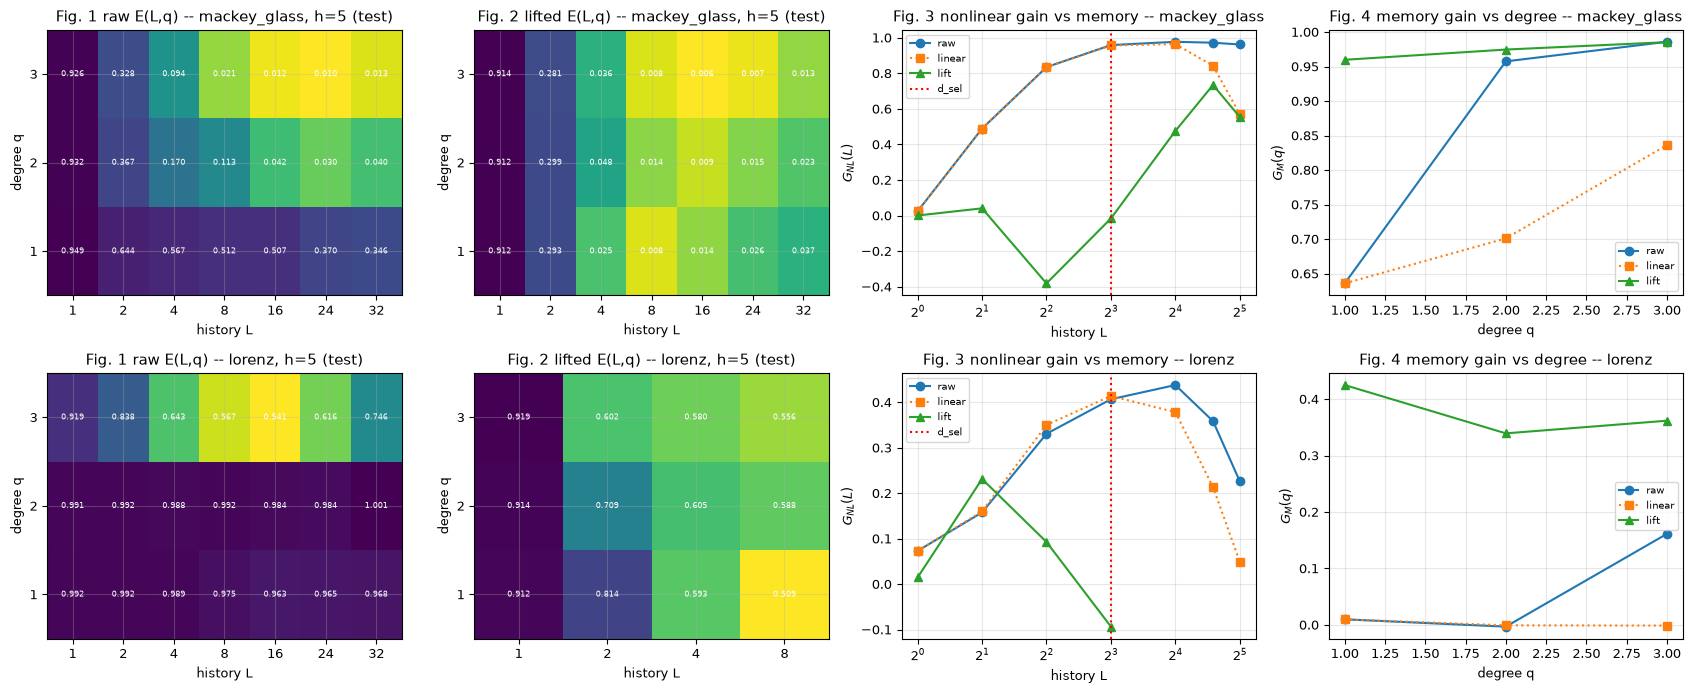

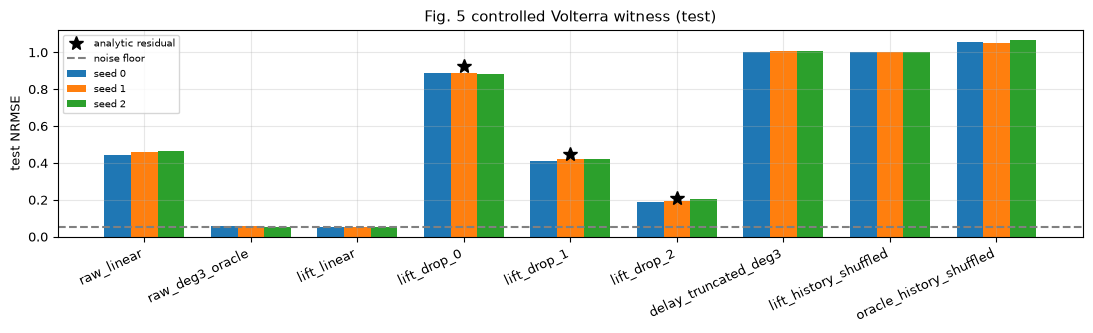

In [22]:
SURF_TEST, VW_TEST = {}, {}
with LEDGER.time('test_surfaces_volterra'):
    VW_TEST = {s: C.volterra_witness({'train': VOLT[s]['train'], 'val': VOLT[s]['val'], 'test': TEST_VOLT[s]}, 'test',
                                     shuffle_seed=s) for s in SEEDS}
    for ds in DATASETS:
        SURF_TEST[ds] = {s: C.response_surface(FULL[ds][s]['train'], FULL[ds][s]['val'], FULL[ds][s]['test'],
                                               LOCKED[ds]['kernel'], CFG['memory_grid'], CFG['degree_grid'], HZ)
                         for s in SEEDS}
print(f"Volterra witness (TEST)  {'model':26s}" + ''.join(f'  seed{s}' for s in SEEDS))
for m in C.VOLTERRA_MODELS:
    print(f"{'':25s}{m:26s}" + ''.join(f'  {VW_TEST[s][m]["nrmse"]:.3f}' for s in SEEDS)
          + (f"   expected {VW_TEST[SEEDS[0]][m]['expected_nrmse']:.3f}" if 'expected_nrmse' in VW_TEST[SEEDS[0]][m] else ''))

hP = 5 if 5 in HZ else HZ[-1]
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for i, ds in enumerate(DATASETS):
    for j, rep in enumerate(('raw', 'lift')):
        Ls = [L for L in CFG['memory_grid'] if all((L, 1, hP) in SURF_TEST[ds][s][rep] for s in SEEDS)]
        M = np.array([[med([SURF_TEST[ds][s][rep][(L, q, hP)][0] for s in SEEDS]) for L in Ls] for q in CFG['degree_grid']])
        a = ax[i, j]
        im = a.imshow(np.log10(M), aspect='auto', cmap='viridis_r', origin='lower')
        for (qi, li), v in np.ndenumerate(M):
            a.text(li, qi, f'{v:.3f}', ha='center', va='center', fontsize=6, color='w')
        a.set_xticks(range(len(Ls)), Ls); a.set_yticks(range(len(CFG['degree_grid'])), CFG['degree_grid'])
        a.set_xlabel('history L'); a.set_ylabel('degree q')
        a.set_title(f"Fig. {1 + j} {'raw' if rep == 'raw' else 'lifted'} E(L,q) -- {ds}, h={hP} (test)")
    a = ax[i, 2]
    for rep, mk in (('raw', 'o-'), ('linear', 's:'), ('lift', '^-')):
        Ls = [L for L in CFG['memory_grid'] if all((L, 1, hP) in SURF_TEST[ds][s][rep] for s in SEEDS)]
        a.plot(Ls, [med([C.nl_gain(SURF_TEST[ds][s][rep], L, CFG['degree_grid'], hP) for s in SEEDS]) for L in Ls], mk, label=rep)
    a.axvline(LOCKED[ds]['kernel'].d, color='r', ls=':', label='d_sel'); a.set_xscale('log', base=2)
    a.set_xlabel('history L'); a.set_ylabel(r'$G_{NL}(L)$'); a.set_title(f'Fig. 3 nonlinear gain vs memory -- {ds}'); a.legend(fontsize=7)
    a = ax[i, 3]
    for rep, mk in (('raw', 'o-'), ('linear', 's:'), ('lift', '^-')):
        Ls = [L for L in CFG['memory_grid'] if all((L, 1, hP) in SURF_TEST[ds][s][rep] for s in SEEDS)]
        gm = [med([(SURF_TEST[ds][s][rep][(min(Ls), q, hP)][0] - SURF_TEST[ds][s][rep][(max(Ls), q, hP)][0])
                   / (SURF_TEST[ds][s][rep][(min(Ls), q, hP)][0] + 1e-6) for s in SEEDS]) for q in CFG['degree_grid']]
        a.plot(CFG['degree_grid'], gm, mk, label=rep)
    a.set_xlabel('degree q'); a.set_ylabel(r'$G_M(q)$'); a.set_title(f'Fig. 4 memory gain vs degree -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); savefig('fig01_04_response_surfaces.png'); plt.show()

fig, ax = plt.subplots(figsize=(11, 3.4))
xs = np.arange(len(C.VOLTERRA_MODELS))
for k, s in enumerate(SEEDS):
    ax.bar(xs + 0.25 * (k - 1), [VW_TEST[s][m]['nrmse'] for m in C.VOLTERRA_MODELS], 0.25, label=f'seed {s}')
ax.plot(xs[3:6], [VW_TEST[SEEDS[0]][m]['expected_nrmse'] for m in C.VOLTERRA_MODELS[3:6]], 'k*', ms=10, label='analytic residual')
ax.axhline(VW_TEST[SEEDS[0]]['noise_floor_nrmse'], color='gray', ls='--', label='noise floor')
ax.set_xticks(xs, C.VOLTERRA_MODELS, rotation=25, ha='right'); ax.set_ylabel('test NRMSE')
ax.set_title('Fig. 5 controlled Volterra witness (test)'); ax.legend(fontsize=7)
plt.tight_layout(); savefig('fig05_volterra_witness.png'); plt.show()

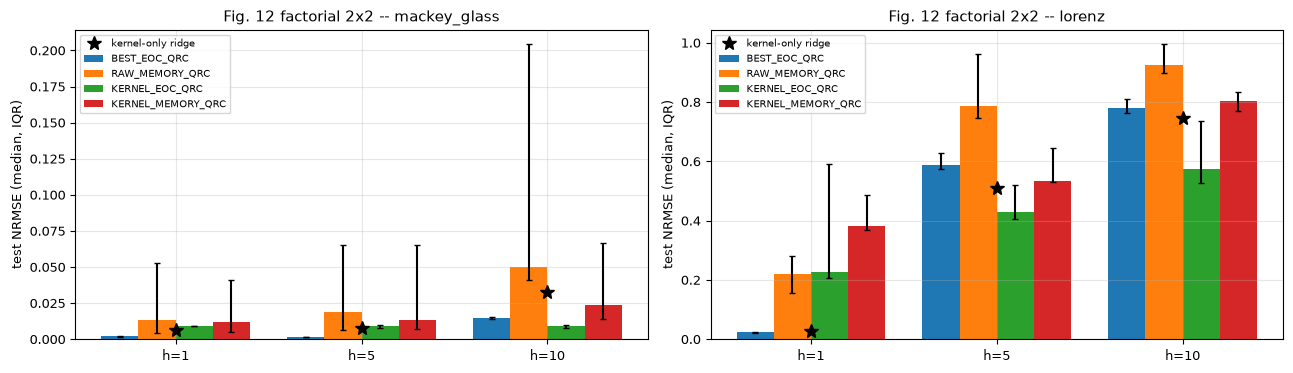

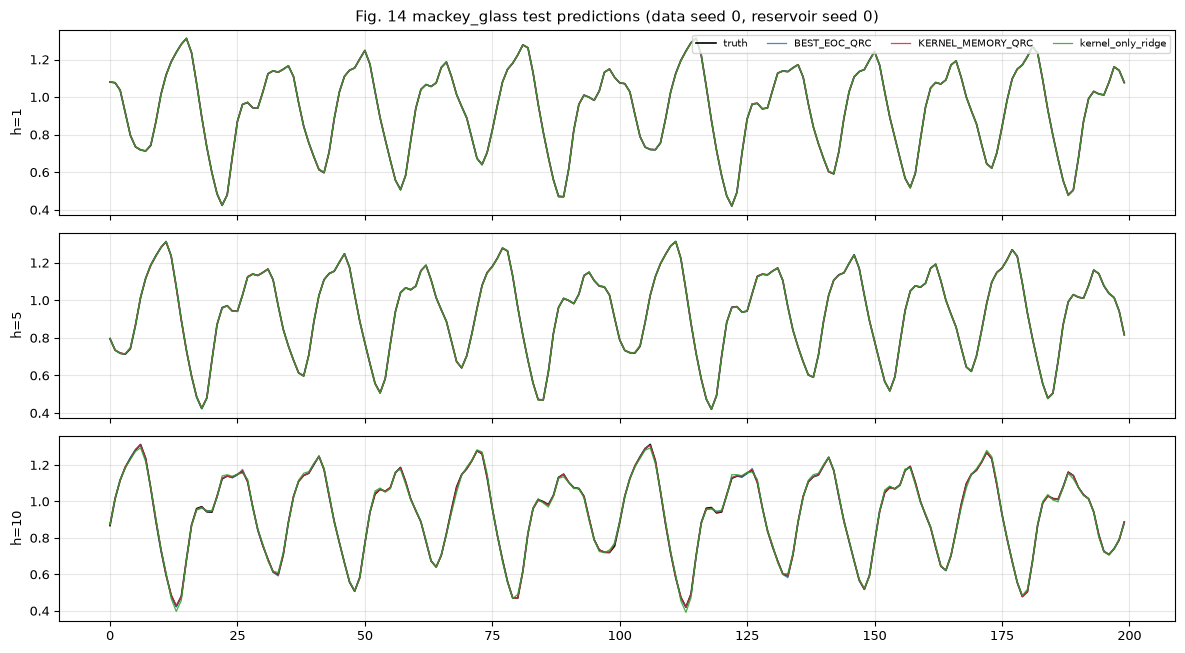

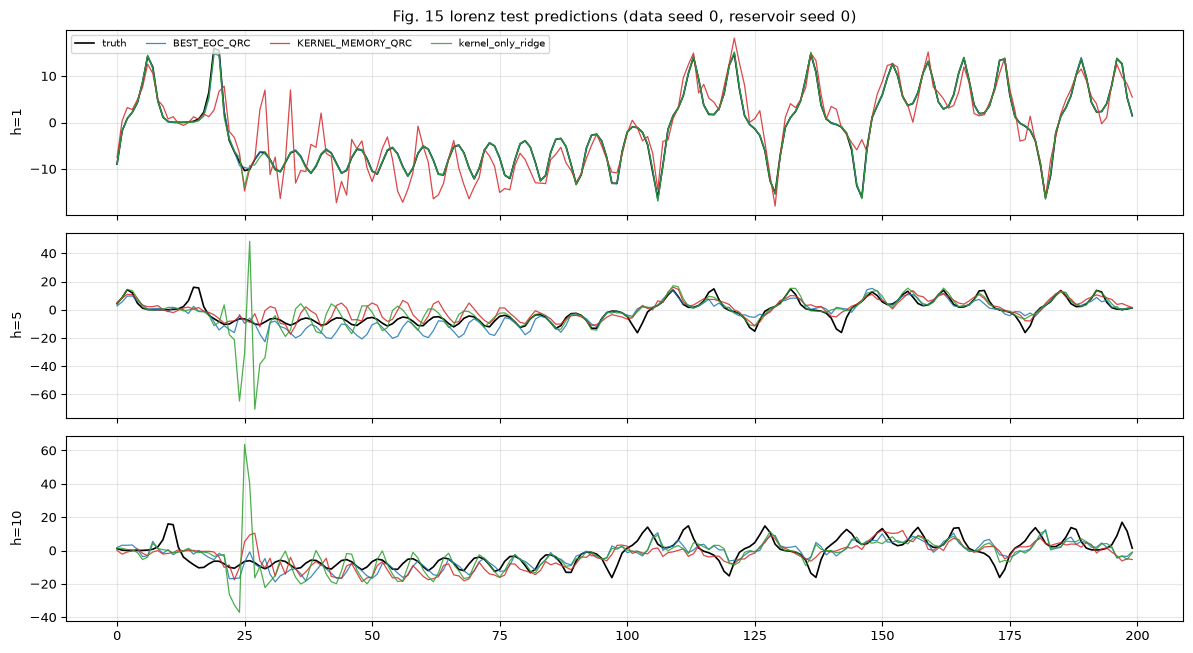

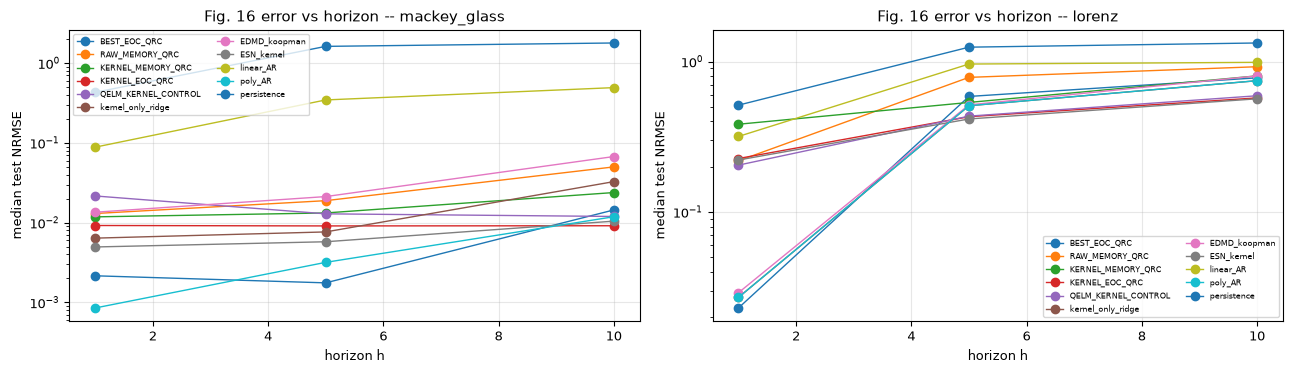

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for a, ds in zip(ax, DATASETS):
    cells = [('BEST_EOC_QRC', 'raw/linear', 'EOC'), ('RAW_MEMORY_QRC', 'raw/linear', 'memory'),
             ('KERNEL_EOC_QRC', 'kernel', 'EOC'), ('KERNEL_MEMORY_QRC', 'kernel', 'memory')]
    w = 0.2
    for k, (m, rep, arm) in enumerate(cells):
        vals = [[r['nrmse']['test'][h] for r in ALLRES[ds][m]] for h in HZ]
        a.bar(np.arange(len(HZ)) + (k - 1.5) * w, [np.median(v) for v in vals], w,
              yerr=[[max(0.0, np.median(v) - np.percentile(v, 25)) for v in vals], [max(0.0, np.percentile(v, 75) - np.median(v)) for v in vals]],
              label=m, capsize=2)
    a.plot(np.arange(len(HZ)), [med([r['nrmse']['test'][h] for r in ALLRES[ds]['kernel_only_ridge']]) for h in HZ], 'k*', ms=10, label='kernel-only ridge')
    a.set_xticks(range(len(HZ)), [f'h={h}' for h in HZ]); a.set_ylabel('test NRMSE (median, IQR)')
    a.set_title(f'Fig. 12 factorial 2x2 -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); savefig('fig12_factorial.png'); plt.show()

for fig_no, ds in ((14, 'mackey_glass'), (15, 'lorenz')):
    fig, ax = plt.subplots(len(HZ), 1, figsize=(12, 2.2 * len(HZ)), sharex=True)
    te = FULL[ds][SEEDS[0]]['test']
    for a, h in zip(ax, HZ):
        k = HZ.index(h)
        a.plot(te.target(h)[:200], 'k', lw=1.2, label='truth')
        for m, c in (('BEST_EOC_QRC', 'C0'), ('KERNEL_MEMORY_QRC', 'C3'), ('kernel_only_ridge', 'C2')):
            r = [r for r in ALLRES[ds][m] if r['unit'] == (SEEDS[0], RSEEDS[0])][0]
            a.plot(r['preds']['test'][:200, k], c, lw=0.9, alpha=0.85, label=m)
        a.set_ylabel(f'h={h}')
    ax[0].legend(fontsize=7, ncol=4); ax[0].set_title(f'Fig. {fig_no} {ds} test predictions (data seed {SEEDS[0]}, reservoir seed {RSEEDS[0]})')
    plt.tight_layout(); savefig(f'fig{fig_no}_{ds}_predictions.png'); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for a, ds in zip(ax, DATASETS):
    for m in ('BEST_EOC_QRC', 'RAW_MEMORY_QRC', 'KERNEL_MEMORY_QRC', 'KERNEL_EOC_QRC', 'QELM_KERNEL_CONTROL',
              'kernel_only_ridge', 'EDMD_koopman', 'ESN_kernel', 'linear_AR', 'poly_AR', 'persistence'):
        a.plot(HZ, [med([r['nrmse']['test'][h] for r in ALLRES[ds][m]]) for h in HZ], 'o-', label=m, lw=1)
    a.set_yscale('log'); a.set_xlabel('horizon h'); a.set_ylabel('median test NRMSE'); a.set_title(f'Fig. 16 error vs horizon -- {ds}')
    a.legend(fontsize=6, ncol=2)
plt.tight_layout(); savefig('fig16_error_vs_horizon.png'); plt.show()

## 19. Statistical uncertainty

Paired moving-block bootstrap over test time indices (2000 draws). Within a data seed, both models and every
reservoir seed share the same resampled indices. The block length is computed first, as max(40, the largest |error|
autocorrelation length over every compared model), rounded up to a multiple of 10 (see the amendment in §1). Reported for each system and horizon:
- $\Delta_{\rm EOC}$ (`KERNEL_MEMORY` vs `BEST_EOC`);
- the comparison with `KERNEL_EOC`;
- $\Delta_{\rm K}$ (`KERNEL_MEMORY` vs kernel-only ridge);
- the raw-input crossover (`BEST_EOC` vs `RAW_MEMORY`).

Per-unit paired results are shown as well.

bootstrap block length (samples): 70 | largest |error| autocorrelation length: 69 from ('mackey_glass', 'RAW_MEMORY_QRC')


dataset         h comparison          E_A      E_B    Delta  95% CI
mackey_glass    1 eoc              0.0022   0.0118   -4.478  [-4.184, -2.216]
mackey_glass    1 kernel_eoc       0.0092   0.0118   -0.283  [-0.193, +0.253]
mackey_glass    1 kernel_only      0.0064   0.0118   -0.848  [-0.676, -0.098]
mackey_glass    1 raw_crossover    0.0130   0.0022   +0.834  [+0.753, +0.835]
mackey_glass    1 mc_eoc           0.0065   0.0147   -1.262  [-1.410, -1.103]
mackey_glass    1 unconstrained    0.0022   0.0118   -4.333  [-4.061, -2.238]
mackey_glass    5 eoc              0.0018   0.0132   -6.519  [-7.614, -4.673]
mackey_glass    5 kernel_eoc       0.0091   0.0132   -0.454  [-0.632, -0.069]
mackey_glass    5 kernel_only      0.0077   0.0132   -0.729  [-0.963, -0.264]
mackey_glass    5 raw_crossover    0.0189   0.0018   +0.907  [+0.844, +0.906]
mackey_glass    5 mc_eoc           0.0036   0.0146   -3.057  [-3.056, -2.473]
mackey_glass    5 unconstrained    0.0016   0.0132   -7.345  [-8.155, -5.0

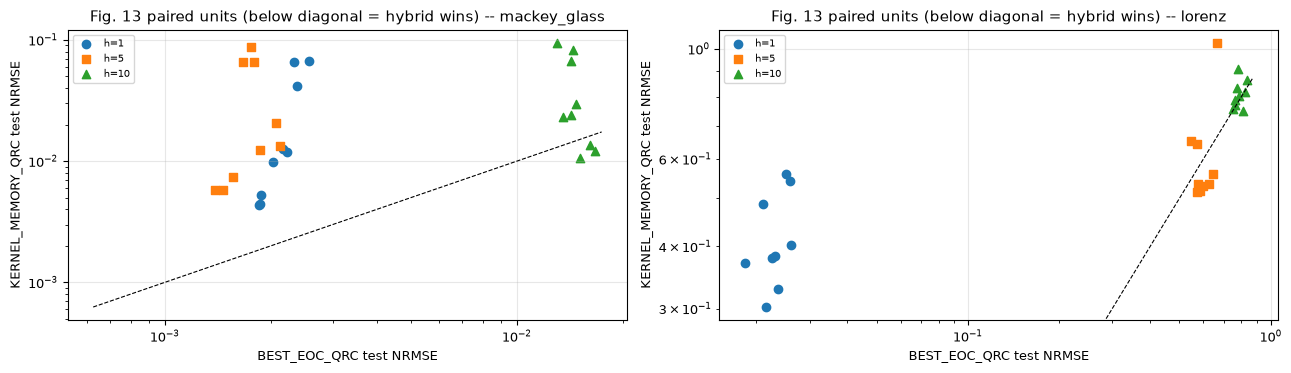

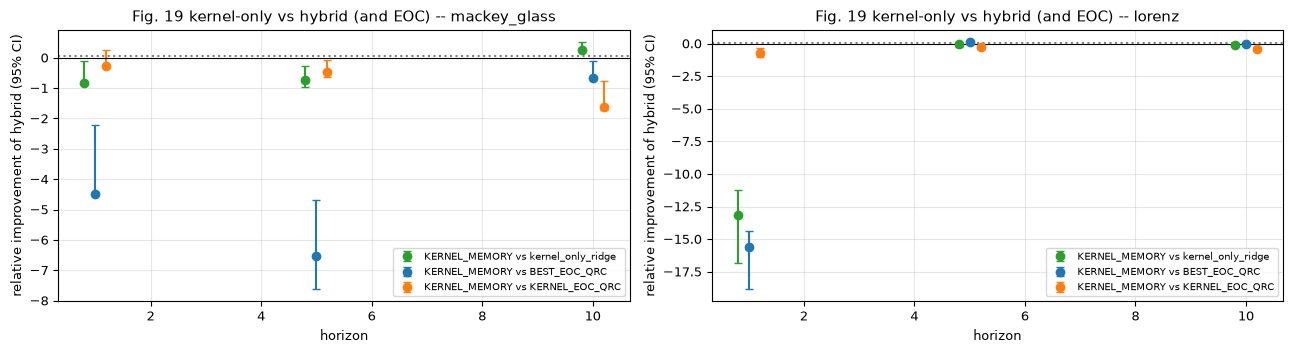

In [24]:
BOOT, BOOT_ROWS = {}, []
ACL_ALL = {}
for ds in DATASETS:
    for m in MAIN + ['ABLATION_DELAY_TRUNCATED', 'ABLATION_HISTORY_SHUFFLED']:
        ACL_ALL[(ds, m)] = max(C.error_autocorr_length(r['preds']['test'][:, HZ.index(h)] - FULL[ds][r['unit'][0]]['test'].target(h))
                               for r in ALLRES[ds][m] for h in HZ)
CFG['block'] = int(10 * np.ceil(max(P.PREREGISTERED['statistics']['block_min'], max(ACL_ALL.values())) / 10))
print('bootstrap block length (samples):', CFG['block'], '| largest |error| autocorrelation length:',
      max(ACL_ALL.values()), 'from', max(ACL_ALL, key=ACL_ALL.get))
COMPARISONS = {'eoc': ('BEST_EOC_QRC', 'KERNEL_MEMORY_QRC'), 'kernel_eoc': ('KERNEL_EOC_QRC', 'KERNEL_MEMORY_QRC'),
               'kernel_only': ('kernel_only_ridge', 'KERNEL_MEMORY_QRC'), 'raw_crossover': ('RAW_MEMORY_QRC', 'BEST_EOC_QRC'),
               'mc_eoc': ('MC_BEST_EOC_QRC', 'MC_KERNEL_MEMORY_QRC'), 'unconstrained': ('UNCONSTRAINED_QRC', 'KERNEL_MEMORY_QRC')}
with LEDGER.time('bootstrap'):
    for ds in DATASETS:
        trajs_test = {s: FULL[ds][s]['test'] for s in SEEDS}
        for h in HZ:
            for name, (a_, b_) in COMPARISONS.items():
                bt = P.compare(ALLRES[ds][a_], ALLRES[ds][b_], trajs_test, HZ, h, CFG, seed=zlib.crc32(f'{ds}|{h}|{name}'.encode()))
                BOOT[(ds, h, name)] = bt
                BOOT_ROWS.append({'dataset': ds, 'h': h, 'comparison': name, 'A': a_, 'B': b_,
                                  'E_A_median': P.median_nrmse(ALLRES[ds][a_], h), 'E_B_median': P.median_nrmse(ALLRES[ds][b_], h),
                                  'delta_(EA-EB)/EA': bt['delta'], 'ci95_lo': bt['ci95'][0], 'ci95_hi': bt['ci95'][1],
                                  'p_delta_le_0': bt['p_le_0']})
print(f"{'dataset':13s} {'h':>3s} {'comparison':14s} {'E_A':>8s} {'E_B':>8s} {'Delta':>8s}  95% CI")
for r in BOOT_ROWS:
    print(f"{r['dataset']:13s} {r['h']:3d} {r['comparison']:14s} {r['E_A_median']:8.4f} {r['E_B_median']:8.4f} "
          f"{r['delta_(EA-EB)/EA']:+8.3f}  [{r['ci95_lo']:+.3f}, {r['ci95_hi']:+.3f}]")
ACL = {ds: max(v for (d_, m), v in ACL_ALL.items() if d_ == ds) for ds in DATASETS}
print('max |error| autocorrelation length (samples) per dataset:', ACL, '| block =', CFG['block'])

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for a, ds in zip(ax, DATASETS):
    for h, mk in zip(HZ, 'os^'):
        ea = {r['unit']: r['nrmse']['test'][h] for r in ALLRES[ds]['BEST_EOC_QRC']}
        eb = {r['unit']: r['nrmse']['test'][h] for r in ALLRES[ds]['KERNEL_MEMORY_QRC']}
        a.scatter([ea[u] for u in UNITS], [eb[u] for u in UNITS], marker=mk, label=f'h={h}')
    lim = a.get_xlim(); a.plot(lim, lim, 'k--', lw=0.8); a.set_xscale('log'); a.set_yscale('log')
    a.set_xlabel('BEST_EOC_QRC test NRMSE'); a.set_ylabel('KERNEL_MEMORY_QRC test NRMSE')
    a.set_title(f'Fig. 13 paired units (below diagonal = hybrid wins) -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); savefig('fig13_paired_units.png'); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, ds in zip(ax, DATASETS):
    for name, c in (('kernel_only', 'C2'), ('eoc', 'C0'), ('kernel_eoc', 'C1')):
        d_ = [BOOT[(ds, h, name)]['delta'] for h in HZ]
        lo = [BOOT[(ds, h, name)]['ci95'][0] for h in HZ]; hi = [BOOT[(ds, h, name)]['ci95'][1] for h in HZ]
        a.errorbar(np.array(HZ) + {'kernel_only': -0.2, 'eoc': 0, 'kernel_eoc': 0.2}[name], d_,
                   [np.clip(np.subtract(d_, lo), 0, None), np.clip(np.subtract(hi, d_), 0, None)], fmt='o', capsize=3, color=c,
                   label=f'KERNEL_MEMORY vs {COMPARISONS[name][0]}')
    a.axhline(0, color='k', lw=0.8); a.axhline(0.05, color='gray', ls=':'); a.set_xlabel('horizon')
    a.set_ylabel('relative improvement of hybrid (95% CI)'); a.set_title(f'Fig. 19 kernel-only vs hybrid (and EOC) -- {ds}')
    a.legend(fontsize=7)
plt.tight_layout(); savefig('fig19_kernel_only_vs_hybrid.png'); plt.show()

## 20. Causal ablations (test, after the lock)

**Classical lifted predictor** (kernel-only ridge on the locked kernel):
- the delay is truncated to $d\in\{1,\lfloor d/4\rfloor,\lfloor d/2\rfloor\}$;
- history is shuffled (current tap kept, past taps from a random other time);
- the lift is replaced by its matched linear embedding;
- lifted coordinates are permuted at test time with the readout fixed;
- individual coordinates are removed one at a time;
- the bandwidth is scaled ×{0.25, 0.5, 1, 2, 4} (RBF), or the degree is switched (polynomial lifts).

**Hybrid QRC** (Aer, re-trained): the delay is truncated to $\lfloor d/4\rfloor$, and the history is shuffled.

The external delay window supplies classical memory of $M_{\rm external}=d$ taps, reported separately from the
QRC's measured MC.


mackey_glass kernel-only ablations (median test NRMSE over data seeds):
   full                         {1: 0.0064, 5: 0.0077, 10: 0.0327}
   linear_embedding             {1: 0.1094, 5: 0.5124, 10: 0.6333}
   history_shuffled             {1: 0.4291, 5: 0.9515, 10: 0.7881}
   delay_truncated_d=1          {1: 0.4204, 5: 0.912, 10: 0.7651}
   delay_truncated_d=2          {1: 0.1357, 5: 0.2931, 10: 0.4864}
   delay_truncated_d=4          {1: 0.0366, 5: 0.0252, 10: 0.0919}
   bandwidth_x0.25              {1: 0.01, 5: 0.0182, 10: 0.0983}
   bandwidth_x0.5               {1: 0.0057, 5: 0.01, 10: 0.0621}
   bandwidth_x2                 {1: 0.0167, 5: 0.017, 10: 0.0304}
   bandwidth_x4                 {1: 0.048, 5: 0.0534, 10: 0.0679}
   coords_permuted_at_test      {1: 48.1975, 5: 99.7902, 10: 250.8}
   leave-one-coordinate-out (h=5): max increase +14.8%, median +2.79% over 40 coordinates
   hybrid KERNEL_MEMORY_QRC          {1: 0.0118, 5: 0.0132, 10: 0.0239}
   hybrid ABLATION_DELAY_TRUNCATED

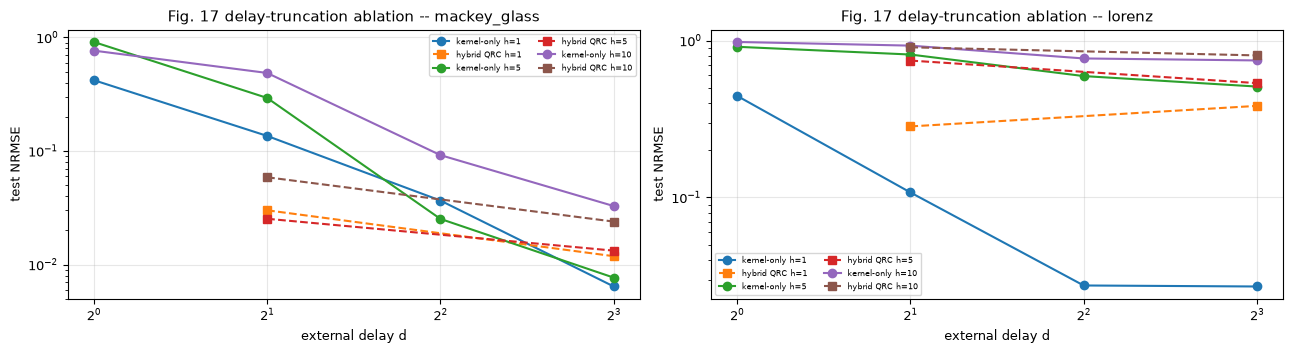

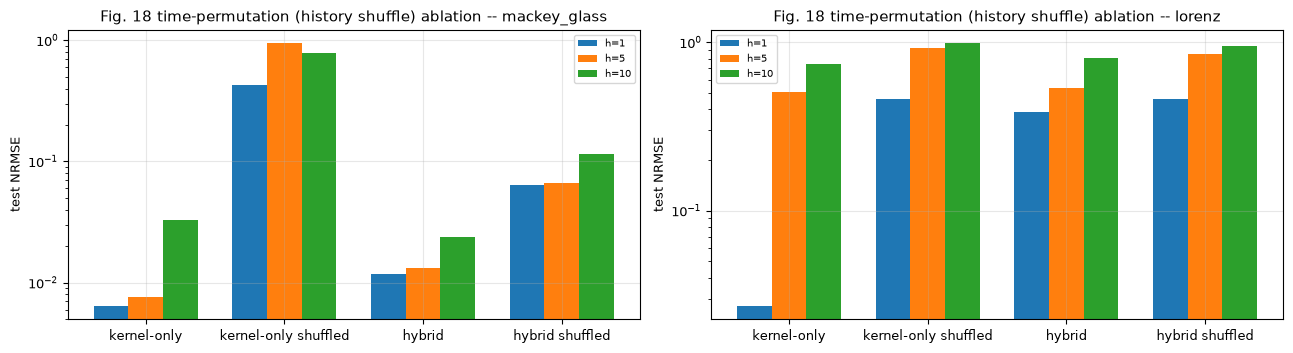

In [25]:
ABL = {ds: {} for ds in DATASETS}
with LEDGER.time('ablations_classical'):
    for ds in DATASETS:
        kern = LOCKED[ds]['kernel']
        def ko(spec, s, S_mode=None, test_perm=None, drop=None):
            tr = FULL[ds][s]
            lf = C.Lifter(spec, H_proj=CFG['H_proj'])
            if S_mode == 'shuffle':
                Sw = {sp: C.history_shuffled_windows(t.x, spec.d, t.eval_idx, seed=(s, C.SPLIT_IDS[sp], 78)) for sp, t in tr.items()}
                lf.fit(tr['train'].x, tr['train'].eval_idx, S_override=Sw['train'])
                F = {sp: lf.psi(t.x, t.eval_idx, S_override=Sw[sp]) for sp, t in tr.items()}
            else:
                lf.fit(tr['train'].x, tr['train'].eval_idx)
                F = {sp: lf.psi(t.x, t.eval_idx) for sp, t in tr.items()}
            if drop is not None:
                F = {sp: np.delete(v, drop, axis=1) for sp, v in F.items()}
            Y = np.stack([tr['train'].target(h) for h in HZ], 1); Yv = np.stack([tr['val'].target(h) for h in HZ], 1)
            m = C.fit_ridge(F['train'], Y, F['val'], Yv)
            Ft = F['test'] if test_perm is None else F['test'][:, test_perm]
            return {'test': m.predict(Ft)}, F['train'].shape[1]
        variants = {'full': (kern, {}), 'linear_embedding': (kern.linear_counterpart(), {}),
                    'history_shuffled': (kern, {'S_mode': 'shuffle'})}
        for dt in sorted({1, max(1, kern.d // 4), max(1, kern.d // 2)}):
            variants[f'delay_truncated_d={dt}'] = (replace(kern, d=dt), {})
        if kern.family == 'rbf':
            for b in (0.25, 0.5, 2.0, 4.0):
                variants[f'bandwidth_x{b:g}'] = (replace(kern, bw=kern.bw * b), {})
        else:
            for fam in ('poly2', 'poly3'):
                if fam != kern.family and C.poly_feature_count(kern.d, int(fam[-1])) <= C.MAX_POLY_FEATURES:
                    variants[f'family={fam}'] = (replace(kern, family=fam), {})
        for name, (spec, kw) in variants.items():
            ABL[ds][name] = [P.classical_result((s, None), ko(spec, s, **kw)[0], FULL[ds][s], HZ, name) for s in SEEDS]
        m_dim = ko(kern, SEEDS[0])[1]
        perm = np.random.default_rng(5).permutation(m_dim)
        ABL[ds]['coords_permuted_at_test'] = [P.classical_result((s, None), ko(kern, s, test_perm=perm)[0], FULL[ds][s], HZ, 'perm') for s in SEEDS]
        drops = range(m_dim) if m_dim <= 40 else np.random.default_rng(6).choice(m_dim, 40, replace=False)
        ABL[ds]['leave_one_coordinate_out'] = {int(j): med([C.nrmse(ko(kern, s, drop=j)[0]['test'][:, HZ.index(hP)],
                                                               FULL[ds][s]['test'].target(hP)) for s in SEEDS]) for j in drops}
ABL_ROWS = []
for ds in DATASETS:
    print(f'\n{ds} kernel-only ablations (median test NRMSE over data seeds):')
    for name, rs_ in ABL[ds].items():
        if name == 'leave_one_coordinate_out':
            v = np.array(list(rs_.values()))
            base = med([r['nrmse']['test'][hP] for r in ABL[ds]['full']])
            print(f'   leave-one-coordinate-out (h={hP}): max increase {100 * (v.max() / base - 1):+.1f}%, '
                  f'median {100 * (np.median(v) / base - 1):+.2f}% over {len(v)} coordinates')
            continue
        e = {h: med([r['nrmse']['test'][h] for r in rs_]) for h in HZ}
        ABL_ROWS.append({'dataset': ds, 'model': 'kernel_only_ridge', 'ablation': name, **{f'nrmse_h{h}': v for h, v in e.items()}})
        print(f'   {name:28s}', {h: round(v, 4) for h, v in e.items()})
    for name in ('KERNEL_MEMORY_QRC', 'ABLATION_DELAY_TRUNCATED', 'ABLATION_HISTORY_SHUFFLED'):
        e = {h: P.median_nrmse(ALLRES[ds][name], h) for h in HZ}
        ABL_ROWS.append({'dataset': ds, 'model': 'hybrid_QRC', 'ablation': name, **{f'nrmse_h{h}': v for h, v in e.items()}})
        print(f'   hybrid {name:26s}', {h: round(v, 4) for h, v in e.items()})

ABL_STATS = {}
for ds in DATASETS:
    trajs_test = {s: FULL[ds][s]['test'] for s in SEEDS}
    kern = LOCKED[ds]['kernel']
    for h in HZ:
        full_ = P.replicate_units(ABL[ds]['full'], (0,))
        for name in (f'delay_truncated_d={max(1, kern.d // 4)}', 'history_shuffled'):
            ABL_STATS[(ds, h, name)] = P.compare(P.replicate_units(ABL[ds][name], (0,)), full_, trajs_test, HZ, h, CFG, seed=11)
        for name in ('ABLATION_DELAY_TRUNCATED', 'ABLATION_HISTORY_SHUFFLED'):
            ABL_STATS[(ds, h, 'hybrid_' + name)] = P.compare(ALLRES[ds][name], ALLRES[ds]['KERNEL_MEMORY_QRC'], trajs_test, HZ, h, CFG, seed=12)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, ds in zip(ax, DATASETS):
    kern = LOCKED[ds]['kernel']
    dts = sorted({1, max(1, kern.d // 4), max(1, kern.d // 2)}) + [kern.d]
    for h in HZ:
        a.plot(dts, [med([r['nrmse']['test'][h] for r in ABL[ds][f'delay_truncated_d={dt}' if dt != kern.d else 'full']]) for dt in dts], 'o-', label=f'kernel-only h={h}')
        a.plot([max(1, kern.d // 4), kern.d], [P.median_nrmse(ALLRES[ds]['ABLATION_DELAY_TRUNCATED'], h), P.median_nrmse(ALLRES[ds]['KERNEL_MEMORY_QRC'], h)], 's--', label=f'hybrid QRC h={h}')
    a.set_xscale('log', base=2); a.set_yscale('log'); a.set_xlabel('external delay d'); a.set_ylabel('test NRMSE')
    a.set_title(f'Fig. 17 delay-truncation ablation -- {ds}'); a.legend(fontsize=6, ncol=2)
plt.tight_layout(); savefig('fig17_delay_truncation.png'); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, ds in zip(ax, DATASETS):
    labels_ = ['kernel-only', 'kernel-only shuffled', 'hybrid', 'hybrid shuffled']
    for k, h in enumerate(HZ):
        v = [med([r['nrmse']['test'][h] for r in ABL[ds]['full']]), med([r['nrmse']['test'][h] for r in ABL[ds]['history_shuffled']]),
             P.median_nrmse(ALLRES[ds]['KERNEL_MEMORY_QRC'], h), P.median_nrmse(ALLRES[ds]['ABLATION_HISTORY_SHUFFLED'], h)]
        a.bar(np.arange(4) + 0.25 * (k - 1), v, 0.25, label=f'h={h}')
    a.set_xticks(range(4), labels_); a.set_yscale('log'); a.set_ylabel('test NRMSE'); a.legend(fontsize=7)
    a.set_title(f'Fig. 18 time-permutation (history shuffle) ablation -- {ds}')
plt.tight_layout(); savefig('fig18_time_permutation.png'); plt.show()

## 21. Runtime and resource analysis

dataset       model                   N in mem    kappa reps  obs  rank      cond  depth    cx
mackey_glass  BEST_EOC_QRC            6  1   5   3.7785    2  132 132.0  2.93e+04    298   164
mackey_glass  RAW_MEMORY_QRC          6  1   5   9.7992    1  132 132.0  3.89e+03    150    82
mackey_glass  KERNEL_MEMORY_QRC       6  1   5   9.7992    1  132 132.0  3.99e+03    150    82
mackey_glass  KERNEL_EOC_QRC          6  1   5   3.7785    2  132 132.0  2.58e+04    298   164
mackey_glass  QELM_KERNEL_CONTROL     6  1   5   3.7785    2  171 171.0  1.13e+05    298   164
mackey_glass  MC_BEST_EOC_QRC         6  2   4   3.7785    2   93  93.0  8.69e+03    298   164
mackey_glass  MC_KERNEL_MEMORY_QRC    6  2   4   9.7992    1   93  93.0  1.43e+03    150    82
mackey_glass  kernel dictionary                                64    64  2.87e+05             
lorenz        BEST_EOC_QRC            6  1   5   4.5177   16  132 132.0  1.21e+03   2370  1312
lorenz        RAW_MEMORY_QRC          6  1   5   9

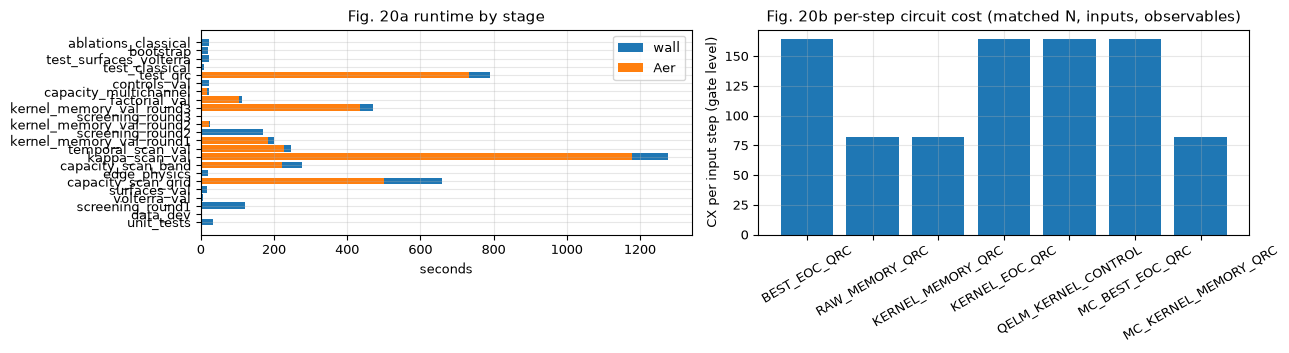

In [26]:
RES_ROWS = []
for ds in DATASETS:
    for m in ('BEST_EOC_QRC', 'RAW_MEMORY_QRC', 'KERNEL_MEMORY_QRC', 'KERNEL_EOC_QRC', 'QELM_KERNEL_CONTROL',
              'MC_BEST_EOC_QRC', 'MC_KERNEL_MEMORY_QRC'):
        rs_ = ALLRES[ds][m]
        rc = rs_[0]['cfg']
        g = Q.gate_level_step_resources(rc)
        RES_ROWS.append({'dataset': ds, 'model': m, 'N': rc.N, 'n_input': rc.n_input, 'memory_qubits': len(rc.memory_qubits),
                         'kappa': round(P.kappa_of(rc), 4), 'reps': rc.reps, 'n_observables': rs_[0]['n_features'],
                         'eff_rank_median': med([r['rank'] for r in rs_]), 'cond_median': med([r['cond'] for r in rs_]), **g})
    lf, _, _ = P.fit_inputs(LOCKED[ds]['kernel'], FULL[ds][SEEDS[0]], CFG)
    Fk = lf.psi(FULL[ds][SEEDS[0]]['train'].x, FULL[ds][SEEDS[0]]['train'].eval_idx)
    RES_ROWS.append({'dataset': ds, 'model': 'kernel dictionary', 'n_observables': Fk.shape[1],
                     'eff_rank_median': C.effective_rank(Fk), 'cond_median': C.condition_number(Fk)})
print(f"{'dataset':13s} {'model':22s} {'N':>2s} {'in':>2s} {'mem':>3s} {'kappa':>8s} {'reps':>4s} {'obs':>4s} {'rank':>5s} {'cond':>9s} {'depth':>6s} {'cx':>5s}")
for r in RES_ROWS:
    print(f"{r['dataset']:13s} {r['model']:22s} {r.get('N', ''):>2} {r.get('n_input', ''):>2} {r.get('memory_qubits', ''):>3} "
          f"{r.get('kappa', ''):>8} {r.get('reps', ''):>4} {r['n_observables']:>4} {r['eff_rank_median']:>5} "
          f"{r['cond_median']:9.2e} {r.get('depth_per_step', ''):>6} {r.get('cx_per_step', ''):>5}")
print('\nstage timings (wall s, Aer s, Aer steps):')
for k, v in LEDGER.timings.items():
    print(f"  {k:28s} {v['wall_s']:8.1f} {v['aer_s']:8.1f} {v['aer_steps']:>10,}")
print('Aer totals:', {k: (round(v, 1) if isinstance(v, float) else v) for k, v in Q.STATS.items()})
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ks = list(LEDGER.timings)
ax[0].barh(ks, [LEDGER.timings[k]['wall_s'] for k in ks], label='wall'); ax[0].barh(ks, [LEDGER.timings[k]['aer_s'] for k in ks], label='Aer')
ax[0].set_xlabel('seconds'); ax[0].legend(); ax[0].set_title('Fig. 20a runtime by stage')
qr = [r for r in RES_ROWS if r['dataset'] == DATASETS[0] and 'N' in r]
ax[1].bar([r['model'] for r in qr], [r['cx_per_step'] for r in qr]); ax[1].set_ylabel('CX per input step (gate level)')
ax[1].tick_params(axis='x', rotation=30); ax[1].set_title('Fig. 20b per-step circuit cost (matched N, inputs, observables)')
plt.tight_layout(); savefig('fig20_runtime_resources.png'); plt.show()

## 22. Pitfall audit

Every check below must pass. A failure raises an `AssertionError` and stops the notebook before the certificate is
written.

In [27]:
print('Audit (earlier sections):', sum(c['pass'] for c in LEDGER.checks), '/', len(LEDGER.checks), 'passed so far\n')
chk = LEDGER.check
# leakage / causality
chk('no target inside an input window (windows end at t, targets start at t+1)',
    all(np.all(t.eval_idx[:, None] - np.arange(CFG['d_max'])[None] <= t.eval_idx[:, None]) and min(HZ) >= 1
        for ds in DATASETS for s in SEEDS for t in FULL[ds][s].values()))
z_a = np.random.default_rng(9).random((80, 1)); z_b = z_a.copy(); z_b[40:] = 1 - z_b[40:]
rcA = Q.mixed_config(CFG['N'], 1, *LOCKED[DATASETS[0]]['memory_key'], 0)
Xa, Xb = Q.run_qrc_jobs([Q.QRCJob(rcA, z_a), Q.QRCJob(rcA, z_b)], chunk=32, use_memo=False)
chk('QRC causality: perturbing inputs from t=40 leaves features t<40 unchanged', max_dev(Xa[:40], Xb[:40]) < 1e-12,
    f'{max_dev(Xa[:40], Xb[:40]):.1e}; after: {max_dev(Xa[40:], Xb[40:]):.2f}')
# train-only preprocessing
for ds in DATASETS:
    for s in SEEDS:
        lf, _, _ = P.fit_inputs(LOCKED[ds]['kernel'], FULL[ds][s], CFG)
        tr = FULL[ds][s]['train']
        ok = lf.n_fit == len(tr.eval_idx) and lf.fit_hash == hash((tr.x[tr.eval_idx].tobytes(), lf.spec))
        chk(f'{ds} s{s}: lift/scaler/projection fitted on the training trajectory only', ok)
        clip = P.fit_inputs(LOCKED[ds]['kernel'], FULL[ds][s], CFG)[2]
        chk(f'{ds} s{s}: test inputs clipped by train scaling < 5% ({100 * clip["test"]:.2f}%)', clip['test'] < 0.05)
        if lf.spec.family == 'rbf':
            g = lf.gram_checks()
            chk(f'{ds} s{s}: RBF Gram not constant/diagonal, no duplicate centres', not (g['nearly_constant'] or g['nearly_diagonal'] or g['duplicate_centres']),
                f"offdiag mean {g['gram_offdiag_mean']:.3f}")
        if lf.spec.family.startswith('poly'):
            chk(f'{ds} s{s}: polynomial feature count <= {C.MAX_POLY_FEATURES}', len(lf.p_mu) <= C.MAX_POLY_FEATURES, len(lf.p_mu))
        ed = C.EDMDPredictor(lf, tr)
        rho = float(np.max(np.abs(np.linalg.eigvals(ed.Am.W.T))))
        roll = ed.predict(FULL[ds][s]['test'], max(HZ))
        chk(f'{ds} s{s}: EDMD rollout stable (|eig A| max {rho:.3f}, finite bounded rollout)',
            np.all(np.isfinite(roll)) and np.abs(roll).max() < 10 * np.abs(tr.x).max())
# trajectories
for ds in DATASETS:
    for s in SEEDS:
        xs = [FULL[ds][s][sp].x for sp in ('train', 'val', 'test')]
        dmin = min(P.min_segment_distance(xs[i], xs[j], CFG['d_max']) for i in range(3) for j in range(i))
        chk(f'{ds} s{s}: train/val/test share no {CFG["d_max"]}-sample segment (min distance {dmin:.3g})', dmin > 1e-6)
# equal evaluation indices and matched resources
for ds in DATASETS:
    lens = {m: tuple(len(r['preds']['test']) for r in ALLRES[ds][m]) for m in MAIN}
    chk(f'{ds}: every model scored on identical test indices', len({v for v in lens.values()}) == 1 and
        all(len(v) == len(UNITS) for v in lens.values()))
    fact = [ALLRES[ds][m] for m in ('BEST_EOC_QRC', 'RAW_MEMORY_QRC', 'KERNEL_MEMORY_QRC', 'KERNEL_EOC_QRC')]
    sig = {(r[0]['cfg'].N, r[0]['cfg'].n_input, len(r[0]['cfg'].memory_qubits), r[0]['n_features'],
            tuple(sorted(x['unit'] for x in r)), tuple(sorted({x['cfg'].seed for x in r}))) for r in fact}
    chk(f'{ds}: factorial QRCs matched (qubits, inputs, memory qubits, observables, units, disorder seeds)', len(sig) == 1, sig)
    mfact = [ALLRES[ds][m] for m in ('MC_BEST_EOC_QRC', 'MC_RAW_MEMORY_QRC', 'MC_KERNEL_MEMORY_QRC', 'MC_KERNEL_EOC_QRC')]
    chk(f'{ds}: multichannel QRCs matched', len({(r[0]['cfg'].N, r[0]['cfg'].n_input, r[0]['n_features']) for r in mfact}) == 1)
    chk(f'{ds}: recurrent factorial QRCs are not QELM', not any(r['cfg'].haar_seed for m in ('KERNEL_MEMORY_QRC', 'BEST_EOC_QRC') for r in ALLRES[ds][m]))
# simulator / test access / budgets / misc
chk('every recurrent QRC used AerSimulator(method="density_matrix")', Q.STATS['recurrent_jobs'] > 0)
chk('deterministic seeds: data regeneration identical', np.array_equal(P.build_split(CFG, 'lorenz', 0, 'train').x, DEV['lorenz'][0]['train'].x))
Xr = Q.run_qrc_jobs([Q.QRCJob(rcA, z_a)], chunk=32, use_memo=False)[0]
chk('deterministic seeds: Aer re-run identical', max_dev(Xr, Xa) == 0.0)
chk('test set released exactly once per dataset, after the lock',
    set(VAULT.releases) == set(DATASETS) | {'volterra'} and all(t > VAULT.lock_time for t in VAULT.releases.values()))
chk('criteria unchanged since the start (hash)', P.criteria_hash() == CRITERIA_HASH == VAULT.criteria_hash_at_lock)
chk('hyperparameter budget: memory/hybrid side <= EOC side', LEDGER.budget['memory_side_val_evals'] <= LEDGER.budget['eoc_side_val_evals'], LEDGER.budget)
chk('bootstrap block >= |error| autocorrelation length', all(v <= CFG['block'] for v in ACL.values()), ACL)
chk('no NaN/inf in any test prediction', all(np.all(np.isfinite(r['preds']['test'])) for ds in DATASETS for m in MAIN for r in ALLRES[ds][m]))
chk('feature rank of every factorial QRC > 1, condition numbers finite',
    all(r['rank'] > 1 and np.isfinite(r['cond']) for ds in DATASETS for m in ('BEST_EOC_QRC', 'KERNEL_MEMORY_QRC') for r in ALLRES[ds][m]))
chk('external delay memory (d taps) and QRC memory (measured MC) both recorded separately',
    all(LOCKED[ds]['kernel'].d >= 1 and 'mc_total' in CAP[LOCKED[ds]['memory_key']] and 'mc_total' in CAP[EOC[ds]['key']] for ds in DATASETS))
chk('source notebooks unmodified', all(sha256(p) == h for p, h in SOURCE_HASHES.items()))
LEDGER.raise_if_failed()
print(f'\nAUDIT: all {len(LEDGER.checks)} checks passed.')

Audit (earlier sections): 38 / 38 passed so far

  [PASS] no target inside an input window (windows end at t, targets start at t+1)
  [PASS] QRC causality: perturbing inputs from t=40 leaves features t<40 unchanged  (0.0e+00; after: 0.23)


  [PASS] mackey_glass s0: lift/scaler/projection fitted on the training trajectory only
  [PASS] mackey_glass s0: test inputs clipped by train scaling < 5% (0.00%)
  [PASS] mackey_glass s0: RBF Gram not constant/diagonal, no duplicate centres  (offdiag mean 0.264)
  [PASS] mackey_glass s0: EDMD rollout stable (|eig A| max 1.001, finite bounded rollout)
  [PASS] mackey_glass s1: lift/scaler/projection fitted on the training trajectory only


  [PASS] mackey_glass s1: test inputs clipped by train scaling < 5% (0.40%)
  [PASS] mackey_glass s1: RBF Gram not constant/diagonal, no duplicate centres  (offdiag mean 0.275)
  [PASS] mackey_glass s1: EDMD rollout stable (|eig A| max 0.996, finite bounded rollout)
  [PASS] mackey_glass s2: lift/scaler/projection fitted on the training trajectory only
  [PASS] mackey_glass s2: test inputs clipped by train scaling < 5% (0.00%)
  [PASS] mackey_glass s2: RBF Gram not constant/diagonal, no duplicate centres  (offdiag mean 0.261)


  [PASS] mackey_glass s2: EDMD rollout stable (|eig A| max 0.995, finite bounded rollout)
  [PASS] lorenz s0: lift/scaler/projection fitted on the training trajectory only
  [PASS] lorenz s0: test inputs clipped by train scaling < 5% (2.40%)
  [PASS] lorenz s0: polynomial feature count <= 600  (164)


  [PASS] lorenz s0: EDMD rollout stable (|eig A| max 0.985, finite bounded rollout)
  [PASS] lorenz s1: lift/scaler/projection fitted on the training trajectory only
  [PASS] lorenz s1: test inputs clipped by train scaling < 5% (0.00%)
  [PASS] lorenz s1: polynomial feature count <= 600  (164)


...

  [PASS] mackey_glass s1: train/val/test share no 32-sample segment (min distance 0.00294)


  [PASS] mackey_glass s2: train/val/test share no 32-sample segment (min distance 0.00516)


  [PASS] lorenz s0: train/val/test share no 32-sample segment (min distance 0.346)


  [PASS] lorenz s1: train/val/test share no 32-sample segment (min distance 0.263)


  [PASS] lorenz s2: train/val/test share no 32-sample segment (min distance 0.162)
  [PASS] mackey_glass: every model scored on identical test indices
  [PASS] mackey_glass: factorial QRCs matched (qubits, inputs, memory qubits, observables, units, disorder seeds)  ({(6, 1, 5, 132, ((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)), (0, 1, 2))})
  [PASS] mackey_glass: multichannel QRCs matched
  [PASS] mackey_glass: recurrent factorial QRCs are not QELM
  [PASS] lorenz: every model scored on identical test indices
  [PASS] lorenz: factorial QRCs matched (qubits, inputs, memory qubits, observables, units, disorder seeds)  ({(6, 1, 5, 132, ((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)), (0, 1, 2))})
  [PASS] lorenz: multichannel QRCs matched
  [PASS] lorenz: recurrent factorial QRCs are not QELM
  [PASS] every recurrent QRC used AerSimulator(method="density_matrix")
  [PASS] deterministic seeds: data regeneration identical
  [PASS] determin

## 23. Machine-readable certificate

The preregistered criteria are evaluated mechanically on the test results; the Boolean logic is the one frozen in
§1. Outputs are `nl_to_memory_evidence.json` plus tidy CSV tables in `results/5_kernel_lifted/`.

In [28]:
PR = P.PREREGISTERED
TC, BC, QC = {}, {}, {}
# ---- TRANSFORMATION -------------------------------------------------------
v1 = [VW_TEST[s]['lift_linear']['nrmse'] <= (1 + PR['transformation']['T1_volterra_lift_within_rel']) * VW_TEST[s]['raw_deg3_oracle']['nrmse'] for s in SEEDS]
v2 = [VW_TEST[s]['raw_linear']['nrmse'] >= (1 + PR['transformation']['T2_volterra_raw_linear_worse_rel']) * VW_TEST[s]['raw_deg3_oracle']['nrmse'] for s in SEEDS]
TC['T1_volterra_lift_matches_oracle'] = all(v1)
TC['T2_volterra_raw_linear_fails'] = all(v2)
G = {}
t3, t3_seed, t4, t4_seed, t5, t5_seed = [], [], [], [], [], []
for ds in DATASETS:
    d_sel = LOCKED[ds]['kernel'].d
    for h in HZ:
        S = SURF_TEST[ds]
        Ls = [L for L in CFG['memory_grid'] if all((L, 1, h) in S[s]['lift'] for s in SEEDS)]
        gr = {s: {L: C.nl_gain(S[s]['raw'], L, CFG['degree_grid'], h) for L in Ls} for s in SEEDS}
        gl = {s: {L: C.nl_gain(S[s]['lift'], L, CFG['degree_grid'], h) for L in Ls} for s in SEEDS}
        gmr = {s: {q: C.memory_gain(S[s]['raw'], q, Ls, h) for q in CFG['degree_grid']} for s in SEEDS}
        gml = {s: {q: C.memory_gain(S[s]['lift'], q, Ls, h) for q in CFG['degree_grid']} for s in SEEDS}
        G[(ds, h)] = {'d_sel': d_sel, 'raw_nl_gain_at_dsel': med([gr[s][d_sel] for s in SEEDS]),
                      'lifted_nl_gain_at_dsel': med([gl[s][d_sel] for s in SEEDS]),
                      'raw_nl_gain_grid_median': med([med(list(gr[s].values())) for s in SEEDS]),
                      'lifted_nl_gain_grid_median': med([med(list(gl[s].values())) for s in SEEDS]),
                      'raw_nl_gain_by_L': {L: med([gr[s][L] for s in SEEDS]) for L in Ls},
                      'lifted_nl_gain_by_L': {L: med([gl[s][L] for s in SEEDS]) for L in Ls},
                      'raw_memory_gain_by_q': {q: med([gmr[s][q] for s in SEEDS]) for q in CFG['degree_grid']},
                      'lifted_memory_gain_by_q': {q: med([gml[s][q] for s in SEEDS]) for q in CFG['degree_grid']}}
        r = PR['transformation']['T3_nl_gain_ratio_max']
        g_ = G[(ds, h)]
        t3.append(g_['lifted_nl_gain_at_dsel'] <= r * g_['raw_nl_gain_at_dsel'] and g_['lifted_nl_gain_grid_median'] <= r * g_['raw_nl_gain_grid_median'])
        t3_seed += [gl[s][d_sel] <= r * gr[s][d_sel] and med(list(gl[s].values())) <= r * med(list(gr[s].values())) for s in SEEDS]
        # T4 memory: lifted L=1 vs L=d_sel, q=1
        ytrue = {s: FULL[ds][s]['test'].target(h) for s in SEEDS}
        pa = {(s, 0): S[s]['lift'][(1, 1, h)][1] for s in SEEDS}; pb = {(s, 0): S[s]['lift'][(d_sel, 1, h)][1] for s in SEEDS}
        bt = C.paired_block_bootstrap(ytrue, pa, pb, CFG['block'], CFG['n_boot'], 21)
        G[(ds, h)]['memory_L1_to_dsel'] = {'delta': bt['delta'], 'ci95': bt['ci95']}
        t4.append(bt['delta'] >= PR['transformation']['T4_memory_min_rel_improvement'] and bt['ci95'][0] > 0)
        t4_seed += [(S[s]['lift'][(1, 1, h)][0] - S[s]['lift'][(d_sel, 1, h)][0]) / S[s]['lift'][(1, 1, h)][0]
                    >= PR['transformation']['T4_memory_min_rel_improvement'] for s in SEEDS]
        # T5 ablations on the kernel-only predictor
        for nm in (f'delay_truncated_d={max(1, d_sel // 4)}', 'history_shuffled'):
            bt = ABL_STATS[(ds, h, nm)]
            ea, eb = med([r['nrmse']['test'][h] for r in ABL[ds][nm]]), med([r['nrmse']['test'][h] for r in ABL[ds]['full']])
            t5.append((ea - eb) / eb >= PR['transformation']['T5_ablation_min_rel_degradation'] and bt['ci95'][0] > 0)
            t5_seed += [(a['nrmse']['test'][h] - b['nrmse']['test'][h]) / b['nrmse']['test'][h] >= PR['transformation']['T5_ablation_min_rel_degradation']
                        for a, b in zip(ABL[ds][nm], ABL[ds]['full'])]
TC['T3_nl_gain_lift_le_half_raw'] = all(t3)
TC['T4_memory_needed_for_lift'] = all(t4)
TC['T5_truncation_and_shuffle_degrade'] = all(t5)
TC['T6_holds_in_every_seed'] = all(v1) and all(v2) and all(t3_seed) and all(t4_seed) and all(t5_seed) and len(SEEDS) >= PR['transformation']['T6_min_seeds']
TC['T7_on_test_trajectories'] = True
TRANSFORMATION_PASS = all(TC.values())
# ---- BEATS_EOC -------------------------------------------------------------
BC['B1_eoc_inside_edge_band'] = all(EOC[ds]['inside_band'] for ds in DATASETS)
BC['B2_reps_validation_selected'] = all(EOC[ds]['reps_validation_selected'] for ds in DATASETS)
per_h = {}
for h in PR['beats_eoc']['B3_nontrivial_horizons']:
    if h not in HZ:
        continue
    d = {ds: BOOT[(ds, h, 'eoc')] for ds in DATASETS}
    lower = all(P.median_nrmse(ALLRES[ds]['KERNEL_MEMORY_QRC'], h) < P.median_nrmse(ALLRES[ds]['BEST_EOC_QRC'], h) for ds in DATASETS)
    ds_sorted = sorted(DATASETS, key=lambda ds: -d[ds]['delta'])
    b4 = d[ds_sorted[0]]['delta'] >= PR['beats_eoc']['B4_min_rel_improvement_one_system'] and d[ds_sorted[1]]['delta'] >= PR['beats_eoc']['B4_min_rel_improvement_other_system']
    b5 = all(d[ds]['ci95'][0] > 0 for ds in DATASETS)
    b7 = all(P.median_nrmse(ALLRES[ds]['KERNEL_MEMORY_QRC'], h) <= (1 + PR['beats_eoc']['B7_max_rel_worse_than_kernel_eoc']) * P.median_nrmse(ALLRES[ds]['KERNEL_EOC_QRC'], h) for ds in DATASETS)
    per_h[h] = {'B3_lower_median_both': lower, 'B4_magnitude': b4, 'B5_ci_excludes_zero': b5, 'B7_not_worse_than_kernel_eoc': b7}
BC['B3_B4_B5_B7_at_some_nontrivial_h'] = any(all(v.values()) for v in per_h.values())
BC['B6_resources_matched'] = all(c['pass'] for c in LEDGER.checks if 'matched' in c['check'])
BEATS_EOC_PASS = all(BC.values())
# ---- QRC VALUE -------------------------------------------------------------
qv = {}
for ds in DATASETS:
    for h in PR['qrc_value']['Q1_horizons']:
        if h in HZ:
            bt = BOOT[(ds, h, 'kernel_only')]
            qv[(ds, h)] = bt['delta'] >= PR['qrc_value']['Q1_min_rel_improvement_over_kernel_only'] and bt['ci95'][0] > 0
QC['Q1_hybrid_beats_kernel_only_somewhere'] = any(qv.values())
QRC_VALUE_PASS = all(QC.values())
FULL_HYPOTHESIS_PASS = (
    TRANSFORMATION_PASS
    and BEATS_EOC_PASS
    and QRC_VALUE_PASS
)
OUTCOME = P.outcome(TRANSFORMATION_PASS, BEATS_EOC_PASS, QRC_VALUE_PASS)
for name, d in (('TRANSFORMATION', TC), ('BEATS_EOC', BC), ('QRC_VALUE', QC)):
    print(name); [print(f'   {k:40s} {v}') for k, v in d.items()]
print('BEATS_EOC per nontrivial horizon:', per_h)
print('QRC_VALUE per (dataset, h):', qv)
print(f'\nTRANSFORMATION_PASS={TRANSFORMATION_PASS}  BEATS_EOC_PASS={BEATS_EOC_PASS}  QRC_VALUE_PASS={QRC_VALUE_PASS}  '
      f'FULL_HYPOTHESIS_PASS={FULL_HYPOTHESIS_PASS}\nOUTCOME: {OUTCOME}')

TRANSFORMATION
   T1_volterra_lift_matches_oracle          True
   T2_volterra_raw_linear_fails             True
   T3_nl_gain_lift_le_half_raw              False
   T4_memory_needed_for_lift                True
   T5_truncation_and_shuffle_degrade        True
   T6_holds_in_every_seed                   False
   T7_on_test_trajectories                  True
BEATS_EOC
   B1_eoc_inside_edge_band                  True
   B2_reps_validation_selected              True
   B3_B4_B5_B7_at_some_nontrivial_h         False
   B6_resources_matched                     True
QRC_VALUE
   Q1_hybrid_beats_kernel_only_somewhere    True
BEATS_EOC per nontrivial horizon: {5: {'B3_lower_median_both': False, 'B4_magnitude': False, 'B5_ci_excludes_zero': False, 'B7_not_worse_than_kernel_eoc': False}, 10: {'B3_lower_median_both': False, 'B4_magnitude': False, 'B5_ci_excludes_zero': False, 'B7_not_worse_than_kernel_eoc': False}}
QRC_VALUE per (dataset, h): {('mackey_glass', 5): False, ('mackey_glass', 10): Tru

In [29]:
hE = max(per_h, key=lambda h: sum(per_h[h].values())) if per_h else HZ[-1]
cap = lambda key: CAP[key]
EVIDENCE = {
    'transformation_pass': TRANSFORMATION_PASS, 'beats_eoc_pass': BEATS_EOC_PASS, 'qrc_value_pass': QRC_VALUE_PASS,
    'full_hypothesis_pass': FULL_HYPOTHESIS_PASS, 'outcome': OUTCOME,
    'criteria_detail': {'transformation': TC, 'beats_eoc': BC, 'beats_eoc_per_h': per_h, 'qrc_value': {f'{k[0]}_h{k[1]}': v for k, v in qv.items()}},
    'raw_nonlinear_gain': {f'{ds}_h{h}': G[(ds, h)]['raw_nl_gain_at_dsel'] for ds in DATASETS for h in HZ},
    'lifted_nonlinear_gain': {f'{ds}_h{h}': G[(ds, h)]['lifted_nl_gain_at_dsel'] for ds in DATASETS for h in HZ},
    'raw_memory_gain': {f'{ds}_h{h}': G[(ds, h)]['raw_memory_gain_by_q'] for ds in DATASETS for h in HZ},
    'lifted_memory_gain': {f'{ds}_h{h}': G[(ds, h)]['lifted_memory_gain_by_q'] for ds in DATASETS for h in HZ},
    'nl_gain_detail': {f'{ds}_h{h}': G[(ds, h)] for ds in DATASETS for h in HZ},
    'controlled_witness_metrics': {f'seed{s}': VW_TEST[s] for s in SEEDS},
    'delay_ablation_metrics': {f'{k[0]}_h{k[1]}_{k[2]}': {'delta': v['delta'], 'ci95': v['ci95']} for k, v in ABL_STATS.items() if 'delay' in k[2].lower()},
    'permutation_metrics': {f'{k[0]}_h{k[1]}_{k[2]}': {'delta': v['delta'], 'ci95': v['ci95']} for k, v in ABL_STATS.items() if 'shuffle' in k[2].lower()},
    'edge_band': [K_LO, K_HI],
    'eoc_kappa': {ds: EOC[ds]['kappa'] for ds in DATASETS}, 'eoc_reps': {ds: EOC[ds]['reps'] for ds in DATASETS},
    'eoc_gap_ratio': {ds: float(np.median(Q.kappa_diagnostics([EOC[ds]['kappa']], CFG['N'], EOC[ds]['reps'], CFG['n_diag_seeds'])['r'])) for ds in DATASETS},
    'eoc_operator_entropy': {ds: [r['S_op'] for r in TEMPORAL_DIAG[ds] if r['reps'] == EOC[ds]['reps']][0] for ds in DATASETS},
    'eoc_scrambling_time': {ds: [r['t_star_layers'] for r in TEMPORAL_DIAG[ds] if r['reps'] == EOC[ds]['reps']][0] for ds in DATASETS},
    'eoc_linear_mc': {ds: cap(EOC[ds]['key'])['mc_total'] for ds in DATASETS},
    'eoc_ipc2': {ds: cap(EOC[ds]['key'])['ipc2'] for ds in DATASETS}, 'eoc_ipc3': {ds: cap(EOC[ds]['key'])['ipc3'] for ds in DATASETS},
    'memory_qrc_kappa': {ds: LOCKED[ds]['memory_key'][0] for ds in DATASETS}, 'memory_qrc_reps': {ds: LOCKED[ds]['memory_key'][1] for ds in DATASETS},
    'memory_qrc_linear_mc': {ds: cap(LOCKED[ds]['memory_key'])['mc_total'] for ds in DATASETS},
    'memory_qrc_ipc2': {ds: cap(LOCKED[ds]['memory_key'])['ipc2'] for ds in DATASETS},
    'memory_qrc_ipc3': {ds: cap(LOCKED[ds]['memory_key'])['ipc3'] for ds in DATASETS},
    'memory_qrc_thresholds_met': {ds: MEM_INFO[ds]['thresholds_met'] for ds in DATASETS},
    'best_eoc_test_nrmse': {f'{ds}_h{h}': P.median_nrmse(ALLRES[ds]['BEST_EOC_QRC'], h) for ds in DATASETS for h in HZ},
    'kernel_memory_test_nrmse': {f'{ds}_h{h}': P.median_nrmse(ALLRES[ds]['KERNEL_MEMORY_QRC'], h) for ds in DATASETS for h in HZ},
    'kernel_eoc_test_nrmse': {f'{ds}_h{h}': P.median_nrmse(ALLRES[ds]['KERNEL_EOC_QRC'], h) for ds in DATASETS for h in HZ},
    'raw_memory_test_nrmse': {f'{ds}_h{h}': P.median_nrmse(ALLRES[ds]['RAW_MEMORY_QRC'], h) for ds in DATASETS for h in HZ},
    'relative_improvement_over_eoc': {f'{ds}_h{h}': BOOT[(ds, h, 'eoc')]['delta'] for ds in DATASETS for h in HZ},
    'improvement_ci95': {f'{ds}_h{h}': BOOT[(ds, h, 'eoc')]['ci95'] for ds in DATASETS for h in HZ},
    'kernel_only_test_nrmse': {f'{ds}_h{h}': P.median_nrmse(ALLRES[ds]['kernel_only_ridge'], h) for ds in DATASETS for h in HZ},
    'qrc_incremental_gain': {f'{ds}_h{h}': {'delta': BOOT[(ds, h, 'kernel_only')]['delta'], 'ci95': BOOT[(ds, h, 'kernel_only')]['ci95']} for ds in DATASETS for h in HZ},
    'selected_delay': {ds: LOCKED[ds]['kernel'].d for ds in DATASETS},
    'selected_kernel': {ds: LOCKED[ds]['kernel'].name for ds in DATASETS},
    'kernel_parameters': {ds: P.jsonable(LOCKED[ds]['kernel']) for ds in DATASETS},
    'external_memory_taps': {ds: LOCKED[ds]['kernel'].d for ds in DATASETS},
    'input_dimension': 1, 'multichannel_input_dimension': CFG['multichannel_p'],
    'dataset_seeds': list(SEEDS), 'reservoir_seeds': list(RSEEDS),
    'qiskit_version': qiskit.__version__, 'qiskit_aer_version': qiskit_aer.__version__, 'device': DEVICE,
    'runtime_seconds': time.perf_counter() - T_START, 'mode': CFG['mode'], 'criteria_hash': CRITERIA_HASH,
    'lock_hash': LOCK_HASH, 'unit_tests': UNIT_TEST_SUMMARY, 'audit_checks_passed': len(LEDGER.checks),
    'nb4_regression_narma2': NB4_REGRESSION, 'validation_rounds_used': N_ROUNDS_USED, 'budget': LEDGER.budget,
    'aer_stats': dict(Q.STATS),
}
EVIDENCE = P.jsonable(EVIDENCE)
with open(os.path.join(RESULTS, 'nl_to_memory_evidence.json'), 'w') as f:
    json.dump(EVIDENCE, f, indent=1, default=str)
P.write_csv(os.path.join(RESULTS, 'capacity_scan.csv'),
            [{'kappa': P.kappa_of(r['cfg']), 'reps': r['cfg'].reps, 'seed': r['seed'], 'n_input': r['cfg'].n_input,
              **{k: r[k] for k in ('mc_total', 'mc_total_unclipped', 'ipc2', 'ipc3', 'ipc2_unthresholded', 'ipc3_unthresholded', 'ipc_null_threshold')}}
             for r in CAP_ROWS])
P.write_csv(os.path.join(RESULTS, 'edge_diagnostics.csv'),
            [{'kappa': k, 'r_median': float(np.median(PHYS['dense']['r'][i])), 'r_q25': float(np.percentile(PHYS['dense']['r'][i], 25)),
              'r_q75': float(np.percentile(PHYS['dense']['r'][i], 75)), 'eta': float(PHYS['eta_dense'][i]),
              'S_op_mean': float(PHYS['dense']['S_op'][i].mean()), 't_star_mean': float(PHYS['dense']['t_star'][i].mean()),
              'in_band': IN_BAND(k)} for i, k in enumerate(CFG['kappa_dense'])])
P.write_csv(os.path.join(RESULTS, 'validation_search.csv'),
            [{**{k: v for k, v in r.items() if k != 'spec'}, 'stage': 'screening'} for ds in DATASETS for r in SCREEN_ROWS[ds]]
            + [{'dataset': k[0], 'stage': 'kappa_scan', 'kappa': k[1], 'input': k[2], 'reps': CFG['reps_ref'], 'J_val': v} for k, v in KJ.items()]
            + [{'dataset': ds, 'stage': 'temporal', 'kappa': k, 'reps': r_, 'J_val': v} for ds in DATASETS for (k, r_), v in TEMPORAL[ds]['J'].items()]
            + [{'dataset': ds, 'stage': 'kernel_memory', 'kernel': nm, 'memory_key': mk, 'J_val': j} for ds in DATASETS for (nm, mk), (_, j) in KM_J[ds].items()]
            + [{'stage': 'round_log', **r} for r in ROUND_LOG])
P.write_csv(os.path.join(RESULTS, 'locked_test_metrics.csv'), TEST_ROWS)
P.write_csv(os.path.join(RESULTS, 'ablations.csv'), ABL_ROWS)
P.write_csv(os.path.join(RESULTS, 'paired_bootstrap.csv'), BOOT_ROWS +
            [{'dataset': k[0], 'h': k[1], 'comparison': 'ablation_' + k[2], 'delta_(EA-EB)/EA': v['delta'],
              'ci95_lo': v['ci95'][0], 'ci95_hi': v['ci95'][1]} for k, v in ABL_STATS.items()])
P.write_csv(os.path.join(RESULTS, 'audit.csv'), LEDGER.checks)
print('wrote', sorted(os.listdir(RESULTS)))
print(json.dumps({k: EVIDENCE[k] for k in ('transformation_pass', 'beats_eoc_pass', 'qrc_value_pass', 'full_hypothesis_pass', 'outcome')}, indent=1))

wrote ['ablations.csv', 'audit.csv', 'capacity_scan.csv', 'edge_diagnostics.csv', 'figures', 'locked_test_metrics.csv', 'nl_to_memory_evidence.json', 'paired_bootstrap.csv', 'validation_search.csv']
{
 "transformation_pass": false,
 "beats_eoc_pass": false,
 "qrc_value_pass": true,
 "full_hypothesis_pass": false,
 "outcome": "5. No support under tested conditions"
}


## 24. Scientific conclusion

The conclusion below is generated from the certificate. It states the outcome reached under the preregistered rules
and does not re-interpret it.

In [30]:
E_ = EVIDENCE
def fmt(d):
    return ', '.join(f'{k}: {v:.4f}' if isinstance(v, float) else f'{k}: {v}' for k, v in d.items())
lines = [f"### Outcome: **{OUTCOME}**", '',
         f"`TRANSFORMATION_PASS={TRANSFORMATION_PASS}`, `BEATS_EOC_PASS={BEATS_EOC_PASS}`, `QRC_VALUE_PASS={QRC_VALUE_PASS}`, "
         f"`FULL_HYPOTHESIS_PASS={FULL_HYPOTHESIS_PASS}` ({CFG['mode']}, {len(SEEDS)} data seeds x {len(RSEEDS)} reservoir seeds, "
         f"N={CFG['N']}, scalar mode).", '']
for ds in DATASETS:
    lk = LOCKED[ds]
    lines += [f"**{ds}.** kernel `{lk['kernel'].name}` (external delay d={lk['kernel'].d} taps); "
              f"EOC kappa={EOC[ds]['kappa']:.3f}, reps={EOC[ds]['reps']} (band [{K_LO:.2f}, {K_HI:.2f}]); "
              f"MEMORY_QRC (kappa, reps)={lk['memory_key']} (thresholds met: {MEM_INFO[ds]['thresholds_met']}); "
              f"BEST_EOC input `{lk['best_eoc_input'].name}`.",
              f"- capacities: EOC MC={E_['eoc_linear_mc'][ds]:.2f}, IPC2={E_['eoc_ipc2'][ds]:.2f}, IPC3={E_['eoc_ipc3'][ds]:.2f}; "
              f"MEMORY MC={E_['memory_qrc_linear_mc'][ds]:.2f}, IPC2={E_['memory_qrc_ipc2'][ds]:.2f}, IPC3={E_['memory_qrc_ipc3'][ds]:.2f}."]
    for h in HZ:
        b, k_ = BOOT[(ds, h, 'eoc')], BOOT[(ds, h, 'kernel_only')]
        lines.append(f"- h={h}: BEST_EOC {P.median_nrmse(ALLRES[ds]['BEST_EOC_QRC'], h):.4f}, RAW_MEMORY {P.median_nrmse(ALLRES[ds]['RAW_MEMORY_QRC'], h):.4f}, "
                     f"KERNEL_MEMORY {P.median_nrmse(ALLRES[ds]['KERNEL_MEMORY_QRC'], h):.4f}, KERNEL_EOC {P.median_nrmse(ALLRES[ds]['KERNEL_EOC_QRC'], h):.4f}, "
                     f"kernel-only {P.median_nrmse(ALLRES[ds]['kernel_only_ridge'], h):.4f} | Delta_EOC={b['delta']:+.3f} "
                     f"[{b['ci95'][0]:+.3f},{b['ci95'][1]:+.3f}], Delta_vs_kernel_only={k_['delta']:+.3f} [{k_['ci95'][0]:+.3f},{k_['ci95'][1]:+.3f}]; "
                     f"G_NL raw={G[(ds, h)]['raw_nl_gain_at_dsel']:.3f} vs lifted={G[(ds, h)]['lifted_nl_gain_at_dsel']:.3f} at L=d_sel")
lines += ['', '**Memory accounting.** The lift itself carries an explicit external delay window of d taps; the recurrent '
          'QRC adds measured fading memory (MC above). The possible mechanistic statement is: nonlinear computation is '
          'relocated into a causal lifting whose required delay depth increases the explicit temporal representation, and '
          'the recurrent QRC then supplies additional fading memory. No claim is made that all memory comes from the QRC.',
          '', '**Criteria that failed:** ' + (', '.join([k for d in (TC, BC, QC) for k, v in d.items() if not v]) or 'none'),
          '', '**Limitations.** FAST_MODE (1,200 training samples per trajectory, 3x3 seeds, N=6, scalar input) ; '
          'the baseline is a Qiskit gate analogue of mixed SYK2/SYK4 dynamics, not the PRL fermionic model; exact '
          'expectation values (no shot noise); the scalar mode compresses the lifted dictionary to one coordinate, which '
          'bounds what the QRC can receive; CIs cover temporal resampling within the fixed seed set, not seed-to-seed '
          'variation beyond the reported per-seed results.']
display(Markdown('\n'.join(lines)))

### Outcome: **5. No support under tested conditions**

`TRANSFORMATION_PASS=False`, `BEATS_EOC_PASS=False`, `QRC_VALUE_PASS=True`, `FULL_HYPOTHESIS_PASS=False` (FAST_MODE, 3 data seeds x 3 reservoir seeds, N=6, scalar mode).

**mackey_glass.** kernel `rbf[m=64,bw=4]|d=8|pred|p=1` (external delay d=8 taps); EOC kappa=3.778, reps=2 (band [3.78, 21.68]); MEMORY_QRC (kappa, reps)=(9.799186, 1) (thresholds met: True); BEST_EOC input `raw(p=1)`.
- capacities: EOC MC=7.55, IPC2=23.31, IPC3=29.27; MEMORY MC=17.76, IPC2=20.82, IPC3=5.79.
- h=1: BEST_EOC 0.0022, RAW_MEMORY 0.0130, KERNEL_MEMORY 0.0118, KERNEL_EOC 0.0092, kernel-only 0.0064 | Delta_EOC=-4.478 [-4.184,-2.216], Delta_vs_kernel_only=-0.848 [-0.676,-0.098]; G_NL raw=0.983 vs lifted=0.073 at L=d_sel
- h=5: BEST_EOC 0.0018, RAW_MEMORY 0.0189, KERNEL_MEMORY 0.0132, KERNEL_EOC 0.0091, kernel-only 0.0077 | Delta_EOC=-6.519 [-7.614,-4.673], Delta_vs_kernel_only=-0.729 [-0.963,-0.264]; G_NL raw=0.959 vs lifted=-0.016 at L=d_sel
- h=10: BEST_EOC 0.0145, RAW_MEMORY 0.0500, KERNEL_MEMORY 0.0239, KERNEL_EOC 0.0092, kernel-only 0.0327 | Delta_EOC=-0.652 [-0.644,-0.105], Delta_vs_kernel_only=+0.270 [+0.266,+0.516]; G_NL raw=0.900 vs lifted=0.511 at L=d_sel
**lorenz.** kernel `poly3|d=8|pred|p=1` (external delay d=8 taps); EOC kappa=4.518, reps=16 (band [3.78, 21.68]); MEMORY_QRC (kappa, reps)=(9.799186, 1) (thresholds met: True); BEST_EOC input `linear|d=8|pred1|p=1`.
- capacities: EOC MC=6.64, IPC2=20.55, IPC3=27.64; MEMORY MC=17.76, IPC2=20.82, IPC3=5.79.
- h=1: BEST_EOC 0.0230, RAW_MEMORY 0.2190, KERNEL_MEMORY 0.3833, KERNEL_EOC 0.2269, kernel-only 0.0271 | Delta_EOC=-15.638 [-18.819,-14.377], Delta_vs_kernel_only=-13.149 [-16.796,-11.230]; G_NL raw=0.508 vs lifted=-1.130 at L=d_sel
- h=5: BEST_EOC 0.5865, RAW_MEMORY 0.7854, KERNEL_MEMORY 0.5352, KERNEL_EOC 0.4301, kernel-only 0.5088 | Delta_EOC=+0.088 [-0.036,+0.113], Delta_vs_kernel_only=-0.052 [-0.259,-0.005]; G_NL raw=0.407 vs lifted=-0.094 at L=d_sel
- h=10: BEST_EOC 0.7799, RAW_MEMORY 0.9242, KERNEL_MEMORY 0.8036, KERNEL_EOC 0.5737, kernel-only 0.7465 | Delta_EOC=-0.030 [-0.071,+0.040], Delta_vs_kernel_only=-0.077 [-0.136,+0.024]; G_NL raw=0.180 vs lifted=-0.005 at L=d_sel

**Memory accounting.** The lift itself carries an explicit external delay window of d taps; the recurrent QRC adds measured fading memory (MC above). The possible mechanistic statement is: nonlinear computation is relocated into a causal lifting whose required delay depth increases the explicit temporal representation, and the recurrent QRC then supplies additional fading memory. No claim is made that all memory comes from the QRC.

**Criteria that failed:** T3_nl_gain_lift_le_half_raw, T6_holds_in_every_seed, B3_B4_B5_B7_at_some_nontrivial_h

**Limitations.** FAST_MODE (1,200 training samples per trajectory, 3x3 seeds, N=6, scalar input) ; the baseline is a Qiskit gate analogue of mixed SYK2/SYK4 dynamics, not the PRL fermionic model; exact expectation values (no shot noise); the scalar mode compresses the lifted dictionary to one coordinate, which bounds what the QRC can receive; CIs cover temporal resampling within the fixed seed set, not seed-to-seed variation beyond the reported per-seed results.

## 25. Exact LONG_RUN configuration

`LONG_RUN = True` executes the same preregistered protocol with the configuration below:
- at least 10,000 usable training samples per real series;
- 5 data seeds × 5 reservoir seeds;
- N = 8 (1 input + 7 memory qubits, 189 observables);
- 20-point κ grid, larger dictionaries and bandwidth grid;
- identical criteria.

The estimate below scales this machine's measured Aer throughput by the density-matrix cost ratio, using a short
N = 8 micro-benchmark.

In [31]:
LONG = P.runtime_config(fast_mode=False, long_run=True)
for k, v in LONG.items():
    if k not in ('kappa_dense', 'esn_grid'):
        print(f'{k:22s} {v}')
rc8 = Q.mixed_config(8, 1, 3.0, 4, 0)
jobs8 = [Q.QRCJob(Q.mixed_config(8, 1, 3.0, 4, s), np.random.default_rng(s).random((256, 1))) for s in range(6)]
t0 = time.perf_counter(); Q.run_qrc_jobs(jobs8, chunk=256, use_memo=False); sps8 = 6 * 256 / (time.perf_counter() - t0)
fast_steps = Q.STATS['aer_steps']
sps6 = Q.STATS['aer_steps'] / max(Q.STATS['aer_seconds'], 1e-9)
scale = (LONG['n_train'] + LONG['n_val'] + 2 * LONG['washout']) / (CFG['n_train'] + CFG['n_val'] + 2 * CFG['washout'])
long_steps = fast_steps * scale * (len(LONG['data_seeds']) * len(LONG['res_seeds'])) / (len(SEEDS) * len(RSEEDS)) * (len(LONG['kappa_grid']) / len(CFG['kappa_grid']))
print(f'\nmeasured throughput: N=6 {sps6:,.0f} steps/s (whole run, {DEVICE}); N=8 {sps8:,.0f} steps/s (micro-benchmark)')
print(f'this run: {fast_steps:,} Aer steps.  LONG_RUN estimate: ~{long_steps:,.0f} steps -> ~{long_steps / sps8 / 3600:.1f} h on this CPU')
print('memory: N=8 density matrix 256x256 complex128 = 1 MiB/trajectory state; per-step memory snapshot 128x128 = 256 KiB, '
      'x chunk 256 = 64 MiB per circuit in flight (batch of 36 -> ~2.3 GiB peak); a 24 GB GPU with qiskit-aer-gpu holds it comfortably.')
print('GPU: rerun on a host where AerSimulator().available_devices() contains "GPU" (e.g. Linux + qiskit-aer-gpu); USE_GPU is auto-detected.')
print(f'\nTotal notebook runtime: {(time.perf_counter() - T_START) / 60:.1f} min')

N                      8
horizons               (1, 5, 10)
nontrivial_horizons    (5, 10)
d_max                  32
washout                100
delay_grid             (1, 2, 4, 8, 16, 24, 32)
memory_grid            (1, 2, 4, 8, 16, 24, 32)
degree_grid            (1, 2, 3)
nystrom_m              (8, 16, 32, 64)
bw_grid                (0.25, 0.5, 1.0, 2.0, 4.0)
projections            ('pred', 'pred1', 'pca')
H_proj                 10
kappa_grid             (0.02, 0.031312, 0.049022, 0.07675, 0.12016, 0.188124, 0.294527, 0.461114, 0.721923, 1.130248, 1.769523, 2.770377, 4.337321, 6.790538, 10.631311, 16.644451, 26.058662, 40.797611, 63.873008, 100.0)
n_diag_seeds           30
n_ref_trials           200
edge_delta_eta         0.1
n_band_points          4
reps_grid              (1, 2, 3, 4, 6, 8, 12, 16)
reps_ref               4
k_mc                   20
k2                     10
k3                     6
shortlist_kernel       5
max_mem_candidates     8
max_validation_rounds  3
proxy_lags   


measured throughput: N=6 784 steps/s (whole run, CPU); N=8 62 steps/s (micro-benchmark)
this run: 2,894,279 Aer steps.  LONG_RUN estimate: ~94,540,492 steps -> ~426.9 h on this CPU
memory: N=8 density matrix 256x256 complex128 = 1 MiB/trajectory state; per-step memory snapshot 128x128 = 256 KiB, x chunk 256 = 64 MiB per circuit in flight (batch of 36 -> ~2.3 GiB peak); a 24 GB GPU with qiskit-aer-gpu holds it comfortably.
GPU: rerun on a host where AerSimulator().available_devices() contains "GPU" (e.g. Linux + qiskit-aer-gpu); USE_GPU is auto-detected.

Total notebook runtime: 77.8 min
